# Vector Data Cubes for Jokulsarlon Glacial Lake

This is a notebook to create a vector data cube (VDC) of the Jokulsarlon glacial lake outlines from 2016 to 2025 based on [original computational notebook](https://github.com/loreabad6/vdc-space-time-feats/blob/main/notebook/vdc-showcase.md) by Abad et al 2024.

**Input data:** `../OBIA_lake_outlines/glacial_lakes_<YYYY>.gpkg`  
**Fields per file:** `id`, `area_m2`, `year`, `geometry`  
**Temporal resolution:** one file per year, multiple polygons per file (one row per lake).

The difference from the lava-flow VDC is that **each lake is a separate feature** tracked across years,  
so the `geom_sum` dimension has one entry per lake (identified by `id`), not just one entry for a single feature.



**Prerequisites:**

Install environment:
```
conda env create -f env.yaml
```
Activate environment:
```
conda activate glacial_lakes
```
Register environment as Jupyter kernel, so it shows in drop down:
```
python -m ipykernel install --user --name glacial_lakes --display-name "glacial_lakes"
```
Update the environment **when finished with code**:
```
conda env export > env.yaml
```

In [2]:
from pathlib import Path

import numpy as np
import xvec
import os
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from shapely.ops import unary_union
from shapely import to_wkt
from shapely.affinity import affine_transform
import matplotlib.cm as cm
from shapely.geometry import Point, box

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Data loading and pre-processing

### 1.1 Read all annual GeoPackages

Each file is named `glacial_lakes_<YYYY>.gpkg`.  
We extract the year from the filename and store it as an integer column `year_ts` (to avoid colliding with the existing `year` attribute field).

In [3]:
DATA_DIR = Path("C:/Users/b1120440/OneDrive - Universität Salzburg/MorphEO/data/OBIA_lake_outlines")

# Find all annual files and sort chronologically
gpkg_files = sorted(DATA_DIR.glob("glacial_lakes_*.gpkg"))
print(f"Found {len(gpkg_files)} files:")
for f in gpkg_files:
    print(f"  {f.name}")

Found 38 files:
  glacial_lakes_1985.gpkg
  glacial_lakes_1986.gpkg
  glacial_lakes_1987.gpkg
  glacial_lakes_1988.gpkg
  glacial_lakes_1989.gpkg
  glacial_lakes_1990.gpkg
  glacial_lakes_1991.gpkg
  glacial_lakes_1992.gpkg
  glacial_lakes_1993.gpkg
  glacial_lakes_1994.gpkg
  glacial_lakes_1995.gpkg
  glacial_lakes_1996.gpkg
  glacial_lakes_1997.gpkg
  glacial_lakes_1998.gpkg
  glacial_lakes_1999.gpkg
  glacial_lakes_2000.gpkg
  glacial_lakes_2001.gpkg
  glacial_lakes_2002.gpkg
  glacial_lakes_2004.gpkg
  glacial_lakes_2005.gpkg
  glacial_lakes_2006.gpkg
  glacial_lakes_2007.gpkg
  glacial_lakes_2010.gpkg
  glacial_lakes_2011.gpkg
  glacial_lakes_2012.gpkg
  glacial_lakes_2013.gpkg
  glacial_lakes_2014.gpkg
  glacial_lakes_2015.gpkg
  glacial_lakes_2016.gpkg
  glacial_lakes_2017.gpkg
  glacial_lakes_2018.gpkg
  glacial_lakes_2019.gpkg
  glacial_lakes_2020.gpkg
  glacial_lakes_2021.gpkg
  glacial_lakes_2022.gpkg
  glacial_lakes_2023.gpkg
  glacial_lakes_2024.gpkg
  glacial_lakes_2025.g

In [4]:
def read_lake_file(path: Path) -> gpd.GeoDataFrame:
    """
    Read a single annual glacial-lake GeoPackage.

    The year is extracted from the filename (glacial_lakes_YYYY.gpkg)
    and stored as an integer in the column `year_ts`.
    Expected attribute fields: id, area_m2, year, geometry.
    """
    gdf = gpd.read_file(path)
    # Extract year from filename as integer
    year_from_fn = int(path.stem.split("_")[-1])  # e.g. 'glacial_lakes_2016' -> 2016
    gdf["year_ts"] = year_from_fn
    gdf["source_file"] = path.name
    return gdf


# Read and concatenate all files
all_lakes = pd.concat([read_lake_file(p) for p in gpkg_files], ignore_index=True)
all_lakes = gpd.GeoDataFrame(all_lakes, geometry="geometry")

print(all_lakes.info())
print(f"\nYears present: {sorted(all_lakes['year_ts'].unique())}")

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   area_m2      193 non-null    float64 
 1   year         193 non-null    int64   
 2   geometry     193 non-null    geometry
 3   year_ts      193 non-null    int64   
 4   source_file  193 non-null    str     
dtypes: float64(1), geometry(1), int64(2), str(1)
memory usage: 7.7 KB
None

Years present: [np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)

In [5]:
print(all_lakes.groupby("year_ts").size())
print(all_lakes.head(20)[["year_ts", "area_m2", "geometry"]])

year_ts
1985    5
1986    6
1987    3
1988    9
1989    4
1990    3
1991    4
1992    3
1993    3
1994    5
1995    6
1996    5
1997    5
1998    5
1999    5
2000    6
2001    6
2002    4
2004    5
2005    6
2006    4
2007    7
2010    6
2011    3
2012    6
2013    5
2014    5
2015    7
2016    6
2017    5
2018    5
2019    5
2020    5
2021    5
2022    4
2023    6
2024    6
2025    5
dtype: int64
    year_ts    area_m2                                           geometry
0      1985   947700.0  POLYGON ((735450 7117050, 735450 7116870, 7354...
1      1985   611100.0  POLYGON ((737100 7116540, 737100 7116510, 7370...
2      1985  9367200.0  POLYGON ((734040 7114620, 734040 7114560, 7340...
3      1985  5228100.0  POLYGON ((726090 7112670, 726090 7112640, 7260...
4      1985   494100.0  POLYGON ((725730 7107900, 725730 7107870, 7257...
5      1986   405000.0  POLYGON ((735840 7119330, 735840 7119300, 7357...
6      1986  2501100.0  POLYGON ((736080 7117830, 736080 7117800, 7360...
7      

### 1.2 Check CRS and reproject if needed

All files should share the same CRS. We reproject everything to a consistent projected CRS for metric calculations.
Adjust the EPSG code below to match your study area (e.g. a local UTM zone).

In [6]:
print(f"Native CRS: {all_lakes.crs}")

# Set target CRS — change EPSG if needed for your region
# For example: 32632 (UTM 32N, Central Europe), 32654 (UTM 54N, High Asia), etc.
TARGET_CRS = all_lakes.crs  # Keep native CRS by default; replace with e.g. 32632

if all_lakes.crs is None:
    raise ValueError("CRS is missing. Set it explicitly: all_lakes = all_lakes.set_crs(<EPSG>)")

all_lakes = all_lakes.to_crs(TARGET_CRS)
print(f"Working CRS: {all_lakes.crs}")

Native CRS: EPSG:32627
Working CRS: EPSG:32627


### 1.3 Validate and fix geometries

In [7]:
invalid = (~all_lakes.geometry.is_valid).sum()
print(f"Invalid geometries before fix: {invalid}")
all_lakes["geometry"] = all_lakes["geometry"].make_valid()
all_lakes_raw = all_lakes.copy()
print(f"Invalid geometries after fix:  {(~all_lakes.geometry.is_valid).sum()}")

Invalid geometries before fix: 0


Invalid geometries after fix:  0


### 1.4 Explore grouping methods
Here we represent four different feature grouping methods:
1. Spatial overlap or roximity to threshold
2. Centroid of temporal union
3. Bounding box of temporal union
4. Automatic representative point
5. Manual representative point

#### 1. Spatial overlap or proximity to threshold
Assign ID for each lake based on spatial overlap or proximity over the years. First year each lake gets an ID. Lakes in the following years are matched to the nearest lake from the previous years if within threshold. If lake is outside threshold, the lake gets a new ID.

In [8]:
def assign_lake_ids_prox(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = None) -> gpd.GeoDataFrame:
    """
    Assign consistent lake IDs across years based on spatial overlap or proximity.
    Lakes in the first year get IDs 1, 2, 3...
    Each subsequent year, a polygon is matched to the nearest prior-year lake
    if within distance_threshold_m; otherwise it gets a new ID.
    """
    years = sorted(all_lakes["year_ts"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1  # placeholder

    next_id = 1

    # Assign IDs to the first year
    first_year_mask = all_lakes["year_ts"] == years[0]
    n_first = first_year_mask.sum()
    all_lakes.loc[first_year_mask, "id"] = range(next_id, next_id + n_first)
    next_id += n_first

    # For each subsequent year, match to previous year by overlap then proximity
    for yr in years[1:]:
        curr_mask = all_lakes["year_ts"] == yr
        curr_idx = all_lakes[curr_mask].index

        # All lakes assigned so far (previous years)
        prev = all_lakes[all_lakes["id"] != -1].copy()

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]

            # 1. Try overlap first
            overlapping = prev[prev.intersects(geom)]
            if not overlapping.empty:
                # Pick the one with the largest intersection area
                best_id = overlapping.copy()
                best_id["overlap"] = overlapping.geometry.intersection(geom).area
                assigned_id = best_id.loc[best_id["overlap"].idxmax(), "id"]
            else:
                # 2. Fall back to nearest within threshold
                distances = prev.geometry.distance(geom)
                min_dist = distances.min()
                if min_dist <= distance_threshold_m:
                    assigned_id = prev.loc[distances.idxmin(), "id"]
                else:
                    # 3. New lake — assign a new ID
                    assigned_id = next_id
                    next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)

    return all_lakes


all_lakes_prox = assign_lake_ids_prox(all_lakes_raw, distance_threshold_m=200)

# Check result
print(all_lakes_prox[["year_ts", "id", "area_m2"]].sort_values(["id", "year_ts"]).to_string())
print(f"\nUnique lake IDs assigned: {sorted(all_lakes_prox['id'].unique())}")
print(f"\nLakes per year:\n{all_lakes_prox.groupby('year_ts')['id'].nunique()}")

     year_ts  id       area_m2
0       1985   1  9.477000e+05
6       1986   1  2.501100e+06
15      1988   1  3.024000e+05
16      1988   1  6.246000e+05
17      1988   1  4.356000e+05
30      1991   1  2.871000e+05
34      1992   1  4.662000e+05
37      1993   1  1.921500e+06
1       1985   2  6.111000e+05
18      1988   2  5.148000e+05
24      1989   2  5.103000e+05
31      1991   2  4.122000e+05
41      1994   2  3.870000e+05
46      1995   2  3.762000e+05
52      1996   2  3.843000e+05
57      1997   2  3.798000e+05
62      1998   2  3.870000e+05
66      1999   2  3.897000e+05
71      2000   2  3.987000e+05
79      2001   2  3.420000e+05
83      2002   2  3.780000e+05
88      2004   2  3.609000e+05
93      2005   2  2.277000e+05
98      2006   2  3.636000e+05
111     2010   2  3.474000e+05
119     2012   2  3.744000e+05
125     2013   2  3.726000e+05
130     2014   2  3.627000e+05
135     2015   2  3.627000e+05
141     2016   2  6.826920e+05
147     2017   2  4.029276e+05
152     

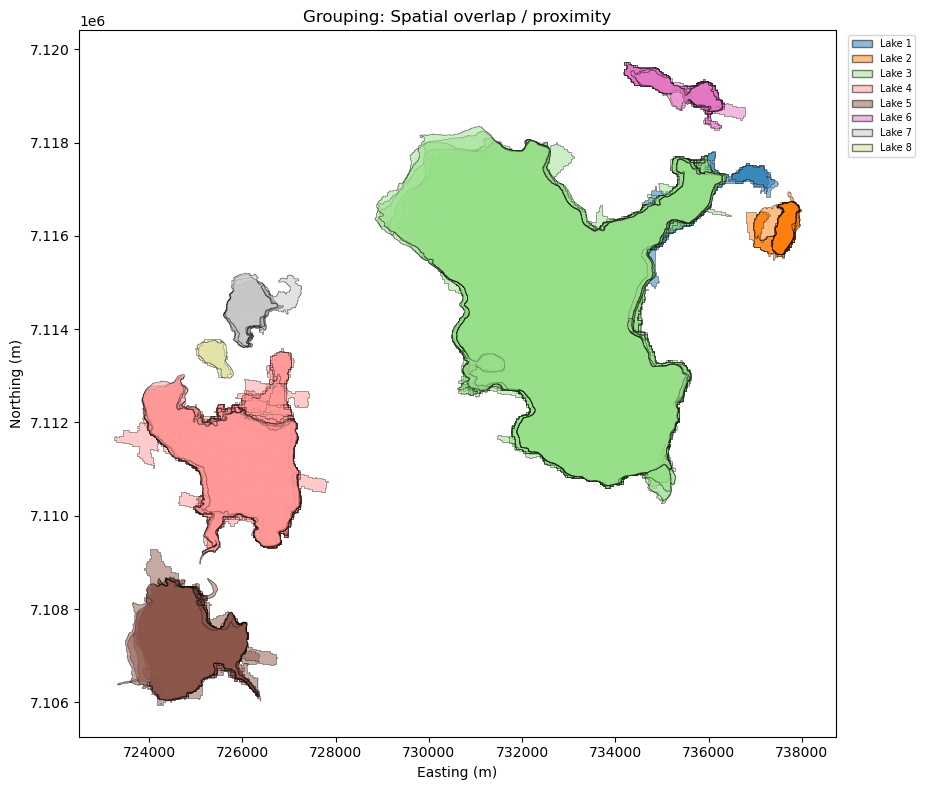

In [ ]:
def plot_lake_ids(gdf: gpd.GeoDataFrame, title: str, save_path: str = None):
    fig, ax = plt.subplots(figsize=(10, 8))
    lake_ids_all = sorted(gdf["id"].unique())
    cmap = plt.cm.tab20
    norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))
    for j, lid in enumerate(lake_ids_all):
        gdf[gdf["id"] == lid].plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)
    legend_handles = [
        Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
        for j, lid in enumerate(lake_ids_all)
    ]
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close()

plot_lake_ids(all_lakes_prox,         "Grouping: Spatial overlap / proximity", "../data/output/lake_ids_overlap.png")

This approach seems to work well with a distance threshold of 200 m for this study area. All seven lakes have individual IDs, and the Jokulsarlon arm that used to be its own lake also has its own ID before the merge. One thing to consider here; should the merged lakes have a new ID, instead of continuing with Jokulsarlons ID? Likely not, as before the merge, the main lake was Jokulsarlon, and now it just has a larger extent.

**We choose this method moving forward**, as from all the methods, it represented reality most accurately.

#### 2. Centroid of temporal union
Assign an ID based on distance to the centroid of `unary_union` of all prior polygons in a group

In [10]:
def assign_lake_ids_centroid(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = None) -> gpd.GeoDataFrame:
    """
    Group polygons across years by proximity to the centroid of the running
    temporal union of each group so far.
    """
    years = sorted(all_lakes["year_ts"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1

    next_id = 1
    # running union per group: {id: Shapely geometry}
    group_union = {}

    # Seed first year
    first_mask = all_lakes["year_ts"] == years[0]
    for i in all_lakes[first_mask].index:
        all_lakes.at[i, "id"] = next_id
        group_union[next_id] = all_lakes.at[i, "geometry"]
        next_id += 1

    for yr in years[1:]:
        curr_idx = all_lakes[all_lakes["year_ts"] == yr].index

        # Build a GeoSeries of group centroids for fast distance query
        group_ids = list(group_union.keys())
        centroids = gpd.GeoSeries(
            [group_union[gid].centroid for gid in group_ids],
            index=group_ids,
            crs=all_lakes.crs,
        )

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]
            distances = centroids.distance(geom.centroid)
            min_dist = distances.min()
            if min_dist <= distance_threshold_m:
                assigned_id = distances.idxmin()
            else:
                assigned_id = next_id
                next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)
            # Update the running union
            if assigned_id in group_union:
                group_union[assigned_id] = group_union[assigned_id].union(geom)
            else:
                group_union[assigned_id] = geom

    return all_lakes


all_lakes_centroid = assign_lake_ids_centroid(all_lakes_raw, distance_threshold_m=2500)
# Check result
print(all_lakes_centroid[["year_ts", "id", "area_m2"]].sort_values(["id", "year_ts"]).to_string())
print(f"\nUnique lake IDs assigned: {sorted(all_lakes_centroid['id'].unique())}")
print(f"\nLakes per year:\n{all_lakes_centroid.groupby('year_ts')['id'].nunique()}")

     year_ts  id       area_m2
0       1985   1  9.477000e+05
6       1986   1  2.501100e+06
16      1988   1  6.246000e+05
17      1988   1  4.356000e+05
34      1992   1  4.662000e+05
37      1993   1  1.921500e+06
47      1995   1  2.331000e+06
72      2000   1  2.169900e+06
78      2001   1  8.892000e+05
94      2005   1  2.475000e+06
1       1985   2  6.111000e+05
15      1988   2  3.024000e+05
18      1988   2  5.148000e+05
24      1989   2  5.103000e+05
30      1991   2  2.871000e+05
31      1991   2  4.122000e+05
41      1994   2  3.870000e+05
46      1995   2  3.762000e+05
52      1996   2  3.843000e+05
57      1997   2  3.798000e+05
62      1998   2  3.870000e+05
66      1999   2  3.897000e+05
71      2000   2  3.987000e+05
79      2001   2  3.420000e+05
83      2002   2  3.780000e+05
88      2004   2  3.609000e+05
93      2005   2  2.277000e+05
98      2006   2  3.636000e+05
111     2010   2  3.474000e+05
119     2012   2  3.744000e+05
125     2013   2  3.726000e+05
130     

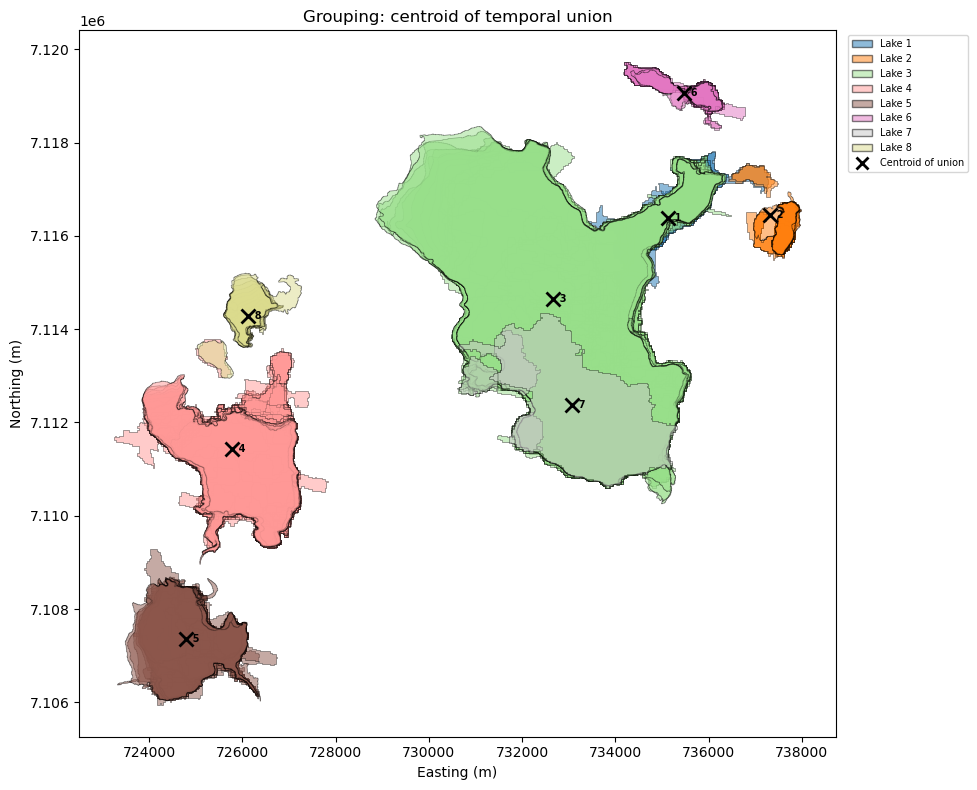

In [71]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_centroid["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

# Compute the centroid of the temporal union per lake (the actual reference geometry used during grouping)
group_centroids = (
    all_lakes_centroid.dropna(subset=["geometry"])
    .groupby("id")["geometry"]
    .apply(lambda g: unary_union(g).centroid)
)

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes_centroid[all_lakes_centroid["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

# Overlay centroids
for j, lid in enumerate(lake_ids_all):
    pt = group_centroids[lid]
    ax.plot(pt.x, pt.y, marker="x", markersize=10, markeredgewidth=2,
            color="black", zorder=5)
    ax.annotate(f"  {lid}", (pt.x, pt.y), fontsize=7, va="center",
                color="black", fontweight="bold")

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
legend_handles.append(
    plt.Line2D([0], [0], marker="x", color="black", linestyle="None",
               markersize=8, markeredgewidth=2, label="Centroid of union")
)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: centroid of temporal union")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig('../data/output/lake_ids_centroid.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach faces challenges with inconsistent lake outlines and lakes with close proximity. The centroid of the temporal union is the average of all coordinates weighted by area of the previous years. As the lake outlines are not accurate, some inconsistent outlines had a centroid too far from the previous years centroid and were assigned a new ID. The distance threshold was set higher (2.5 km) to reduce the number of IDs assigned for Jokulsarlon (3), but still one older ID (7) remains. The higher threshold starts to mix up nearby lakes such as the small lake (8) with Breidarlon (4) and the water body between lakes 1 and 2. 

#### 3. Bounding box of temporal union
Assign IDs based on intersection or distance to the bbox of `unary_union` of all prior polygons.

In [12]:
def assign_lake_ids_bbox(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = None) -> gpd.GeoDataFrame:
    """
    Group polygons across years using the bounding box (envelope) of the running
    temporal union of each group as the reference geometry.
    A new polygon is assigned to a group if it intersects or is within
    distance_threshold_m of that group's bbox.
    """
    years = sorted(all_lakes["year_ts"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1

    next_id = 1
    group_union = {}

    first_mask = all_lakes["year_ts"] == years[0]
    for i in all_lakes[first_mask].index:
        all_lakes.at[i, "id"] = next_id
        group_union[next_id] = all_lakes.at[i, "geometry"]
        next_id += 1

    for yr in years[1:]:
        curr_idx = all_lakes[all_lakes["year_ts"] == yr].index

        group_ids = list(group_union.keys())
        bboxes = gpd.GeoSeries(
            [group_union[gid].envelope for gid in group_ids],
            index=group_ids,
            crs=all_lakes.crs,
        )

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]

            # First: overlap with any bbox
            overlapping = bboxes[bboxes.intersects(geom)]
            if not overlapping.empty:
                # pick bbox with largest intersection area
                best = overlapping.copy().to_frame("bbox_geom")
                best["overlap"] = overlapping.intersection(geom).area
                assigned_id = best["overlap"].idxmax()
            else:
                distances = bboxes.distance(geom)
                min_dist = distances.min()
                if min_dist <= distance_threshold_m:
                    assigned_id = distances.idxmin()
                else:
                    assigned_id = next_id
                    next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)
            if assigned_id in group_union:
                group_union[assigned_id] = group_union[assigned_id].union(geom)
            else:
                group_union[assigned_id] = geom

    return all_lakes


all_lakes_bbox = assign_lake_ids_bbox(all_lakes_raw, distance_threshold_m=10)
# Check result
print(all_lakes_bbox[["year_ts", "id", "area_m2"]].sort_values(["id", "year_ts"]).to_string())
print(f"\nUnique lake IDs assigned: {sorted(all_lakes_bbox['id'].unique())}")
print(f"\nLakes per year:\n{all_lakes_bbox.groupby('year_ts')['id'].nunique()}")

     year_ts  id       area_m2
0       1985   1  9.477000e+05
6       1986   1  2.501100e+06
15      1988   1  3.024000e+05
16      1988   1  6.246000e+05
17      1988   1  4.356000e+05
30      1991   1  2.871000e+05
34      1992   1  4.662000e+05
37      1993   1  1.921500e+06
78      2001   1  8.892000e+05
1       1985   2  6.111000e+05
18      1988   2  5.148000e+05
24      1989   2  5.103000e+05
31      1991   2  4.122000e+05
41      1994   2  3.870000e+05
46      1995   2  3.762000e+05
52      1996   2  3.843000e+05
57      1997   2  3.798000e+05
62      1998   2  3.870000e+05
66      1999   2  3.897000e+05
71      2000   2  3.987000e+05
79      2001   2  3.420000e+05
83      2002   2  3.780000e+05
88      2004   2  3.609000e+05
93      2005   2  2.277000e+05
98      2006   2  3.636000e+05
111     2010   2  3.474000e+05
119     2012   2  3.744000e+05
125     2013   2  3.726000e+05
130     2014   2  3.627000e+05
135     2015   2  3.627000e+05
141     2016   2  6.826920e+05
147     

Plot the outlines and the bounding boxes of the temporal union per lake. Note that bounding box is created for the most recent extent, and the box varies through the years.

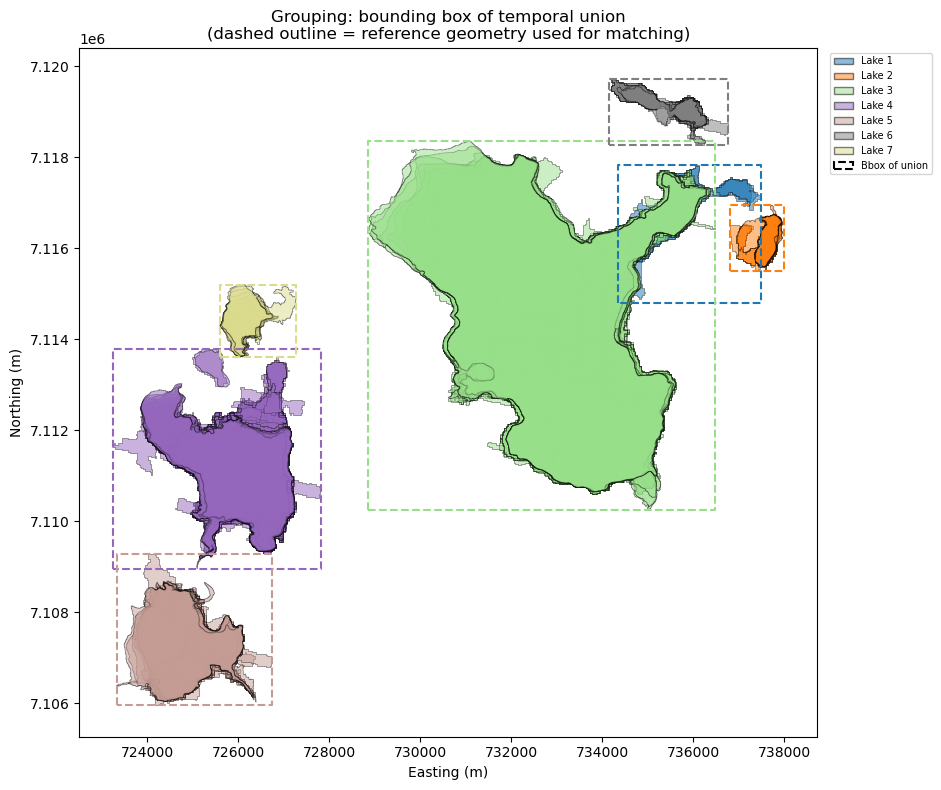

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_bbox["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

# Compute the bounding box of the temporal union per lake
group_bboxes = (
    all_lakes_bbox.dropna(subset=["geometry"])
    .groupby("id")["geometry"]
    .apply(lambda g: unary_union(g).envelope)
)
group_bboxes = gpd.GeoSeries(group_bboxes, crs=all_lakes_bbox.crs)

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes_bbox[all_lakes_bbox["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

# Overlay bounding boxes as outlines only (no fill, so polygons remain visible)
for j, lid in enumerate(lake_ids_all):
    gpd.GeoSeries([group_bboxes[lid]]).plot(
        ax=ax, facecolor="none", edgecolor=cmap(norm(j)),
        linewidth=1.5, linestyle="--", zorder=5
    )

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
legend_handles.append(
    Patch(facecolor="none", edgecolor="k", linewidth=1.5,
          linestyle="--", label="Bbox of union")
)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: bounding box of temporal union\n(dashed outline = reference geometry used for matching)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig('../data/output/lake_ids_bbox.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach has difficulty classifying lakes that are spatially nested within another lake. As lake 4 curves inward on the northern side, its bounding box encloses a smaller neighbouring lake, causing it to be misclassified even at a distance threshold of 10 m.

#### 4. Representative point
Assign IDs based on distance to `representative_point()` by `shapely` of `unary_union` of all prior polygons.

In [14]:
def assign_lake_ids_repr_point(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = None) -> gpd.GeoDataFrame:
    """
    Group polygons using the representative_point() of the running temporal union.
    Unlike centroid, representative_point() always lies inside the polygon,
    making it more robust for concave or fragmented shapes.
    """
    years = sorted(all_lakes["year_ts"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1

    next_id = 1
    group_union = {}

    first_mask = all_lakes["year_ts"] == years[0]
    for i in all_lakes[first_mask].index:
        all_lakes.at[i, "id"] = next_id
        group_union[next_id] = all_lakes.at[i, "geometry"]
        next_id += 1

    for yr in years[1:]:
        curr_idx = all_lakes[all_lakes["year_ts"] == yr].index

        group_ids = list(group_union.keys())
        repr_pts = gpd.GeoSeries(
            [group_union[gid].representative_point() for gid in group_ids],
            index=group_ids,
            crs=all_lakes.crs,
        )

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]
            distances = repr_pts.distance(geom.centroid)
            min_dist = distances.min()
            if min_dist <= distance_threshold_m:
                assigned_id = distances.idxmin()
            else:
                assigned_id = next_id
                next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)
            if assigned_id in group_union:
                group_union[assigned_id] = group_union[assigned_id].union(geom)
            else:
                group_union[assigned_id] = geom

    return all_lakes


all_lakes_repr = assign_lake_ids_repr_point(all_lakes_raw, distance_threshold_m=2500)
# Check result
print(all_lakes_repr[["year_ts", "id", "area_m2"]].sort_values(["id", "year_ts"]).to_string())
print(f"\nUnique lake IDs assigned: {sorted(all_lakes_repr['id'].unique())}")
print(f"\nLakes per year:\n{all_lakes_repr.groupby('year_ts')['id'].nunique()}")

     year_ts  id       area_m2
0       1985   1  9.477000e+05
6       1986   1  2.501100e+06
16      1988   1  6.246000e+05
17      1988   1  4.356000e+05
34      1992   1  4.662000e+05
37      1993   1  1.921500e+06
47      1995   1  2.331000e+06
72      2000   1  2.169900e+06
78      2001   1  8.892000e+05
94      2005   1  2.475000e+06
1       1985   2  6.111000e+05
15      1988   2  3.024000e+05
18      1988   2  5.148000e+05
24      1989   2  5.103000e+05
30      1991   2  2.871000e+05
31      1991   2  4.122000e+05
41      1994   2  3.870000e+05
46      1995   2  3.762000e+05
52      1996   2  3.843000e+05
57      1997   2  3.798000e+05
62      1998   2  3.870000e+05
66      1999   2  3.897000e+05
71      2000   2  3.987000e+05
79      2001   2  3.420000e+05
83      2002   2  3.780000e+05
88      2004   2  3.609000e+05
93      2005   2  2.277000e+05
98      2006   2  3.636000e+05
111     2010   2  3.474000e+05
119     2012   2  3.744000e+05
125     2013   2  3.726000e+05
130     

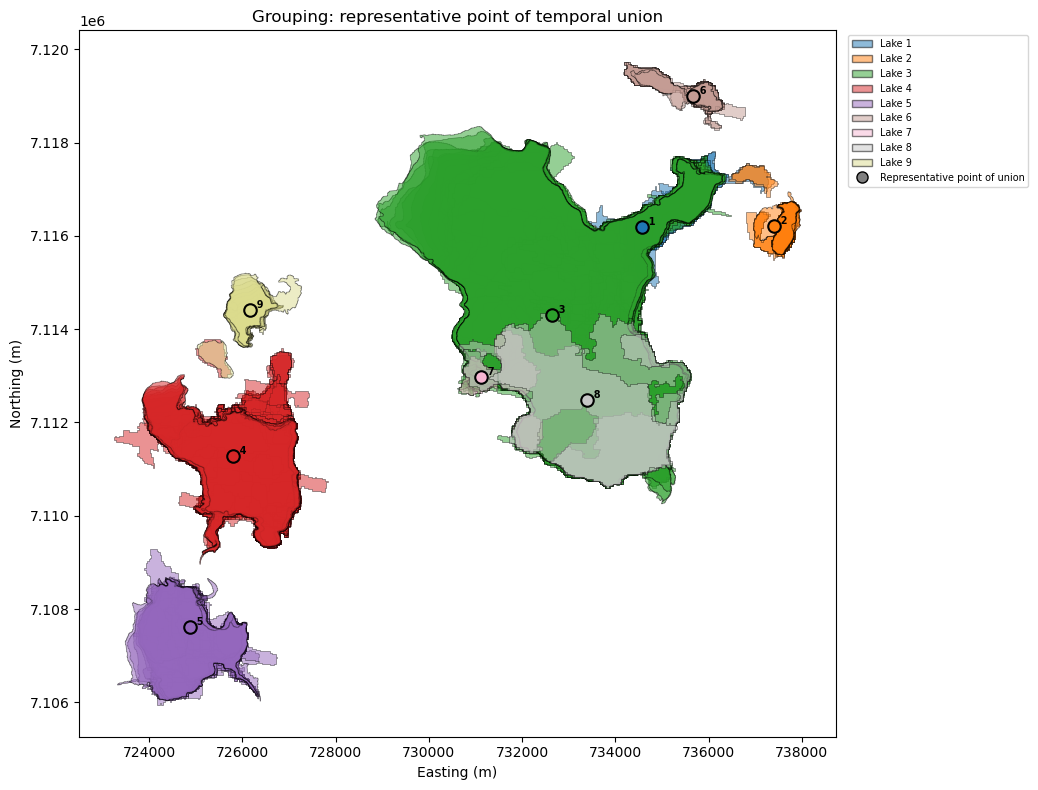

In [70]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_repr["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

# Compute the representative point of the temporal union per lake
group_repr_pts = (
    all_lakes_repr.dropna(subset=["geometry"])
    .groupby("id")["geometry"]
    .apply(lambda g: unary_union(g).representative_point())
)

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes_repr[all_lakes_repr["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

# Overlay representative points as filled circles (distinct from centroid's ×)
for j, lid in enumerate(lake_ids_all):
    pt = group_repr_pts[lid]
    ax.plot(pt.x, pt.y, marker="o", markersize=9, markeredgewidth=1.5,
            markerfacecolor=cmap(norm(j)), markeredgecolor="k", zorder=5)
    ax.annotate(f"  {lid}", (pt.x, pt.y), fontsize=7, va="bottom",
                color="black", fontweight="bold")

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
legend_handles.append(
    plt.Line2D([0], [0], marker="o", color="k", linestyle="None",
               markersize=8, markerfacecolor="gray", markeredgecolor="k",
               label="Representative point of union")
)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: representative point of temporal union")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig('../data/output/lake_ids_repr_point.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach is very similar to the centroid method.The difference is that while the centroid of the temporal union can fall outside the polygon for irregular or concave shapes, the representative point is guaranteed to lie inside it. This is because `shapely`s `representative_point()` chooses the midpoint of the longest east-west line inside the polygon, rather than the geometric centre of mass. However, with the same distance threshold (2.5 km), representative point method has the same difficulties with nearby lakes as centroid (lakes 4 and 9, and lakes 1 and 2), with an additional ID (7) within Jokulsarlon.

#### 5. Manual representative point

Assign IDs based on manually chosen representative points of `unary_union` of all prior polygons.

In [16]:
repr_pts_manual = gpd.read_file(os.path.join(DATA_DIR, "representative_points.gpkg"))
repr_pts_manual = repr_pts_manual.to_crs(all_lakes_raw.crs)

print(repr_pts_manual)

   lake_id                        geometry
0        1  POINT (734291.525 7111379.698)
1        2  POINT (726389.482 7111125.885)
2        3  POINT (725729.568 7107335.612)
3        4   POINT (737641.856 7115931.41)
4        5  POINT (735459.065 7119180.216)
5        6   POINT (726221.994 7114335.38)
6        7  POINT (725411.039 7113441.251)
7        8  POINT (735002.201 7116354.432)


In [17]:
def assign_lake_ids_manual_repr(all_lakes: gpd.GeoDataFrame, repr_points: gpd.GeoDataFrame, distance_threshold_m: float = None, point_id_col: str = "lake_id",) -> gpd.GeoDataFrame:
    """
    Assign lake IDs based on proximity to manually defined representative points of the temporal union.
    Each point in repr_points represents one lake group.
    A polygon is assigned to the nearest point within distance_threshold_m.
    If no point is within threshold, the polygon gets a new ID.
    """
    years = sorted(all_lakes["year_ts"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1


    next_new_id = max(repr_points[point_id_col]) + 1
    
    # Initialise the running union from the manual points (as tiny buffers,
    # so unary_union has a real geometry to work with from the start)
    group_union = {
        row[point_id_col]: row["geometry"].buffer(1)
        for _, row in repr_points.iterrows()
    }

    for yr in years:
        curr_idx = all_lakes[all_lakes["year_ts"] == yr].index

        group_ids = list(group_union.keys())
        repr_pts_running = gpd.GeoSeries(
            [group_union[gid].representative_point() for gid in group_ids],
            index=group_ids,
            crs=all_lakes.crs,
        )

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]
            if geom is None or geom.is_empty:
                continue
            distances = repr_pts_running.distance(geom.centroid)
            min_dist = distances.min()
            if min_dist <= distance_threshold_m:
                assigned_id = distances.idxmin()
            else:
                assigned_id = next_new_id
                next_new_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)
            if assigned_id in group_union:
                group_union[assigned_id] = group_union[assigned_id].union(geom)
            else:
                group_union[assigned_id] = geom

    return all_lakes


all_lakes_manual = assign_lake_ids_manual_repr(
    all_lakes_raw,
    repr_points=repr_pts_manual,
    distance_threshold_m=3000,
    point_id_col="lake_id",
)

print(f"Unique IDs assigned: {sorted(all_lakes_manual['id'].unique())}")

Unique IDs assigned: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


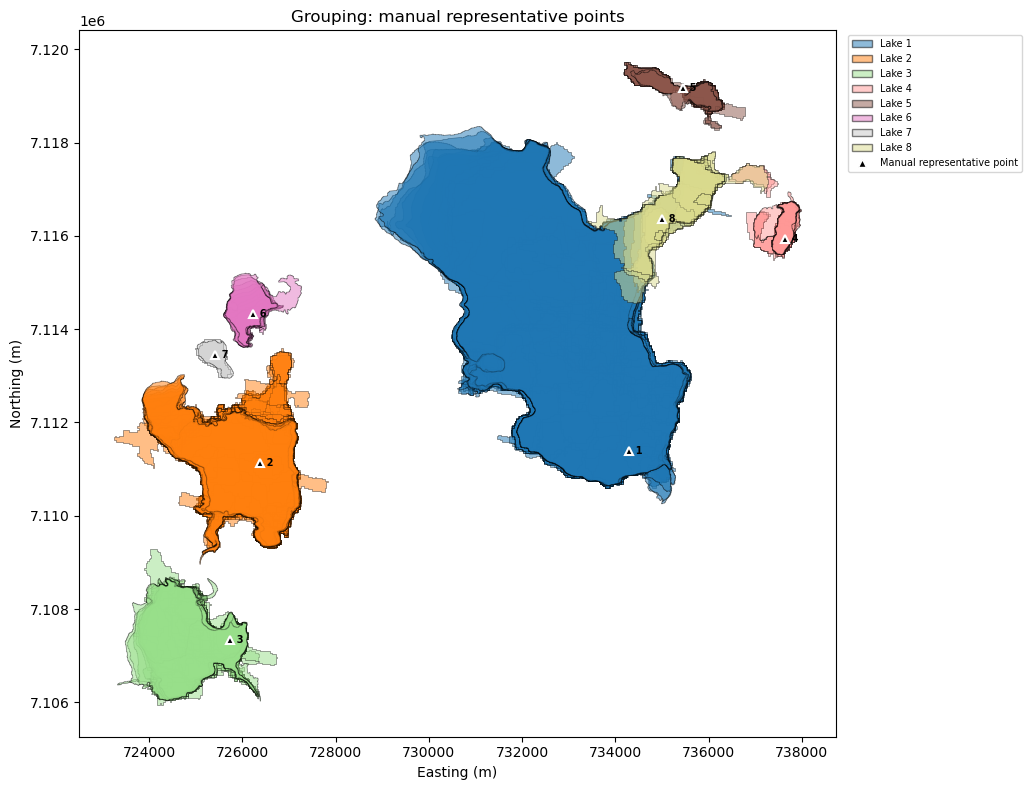

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_manual["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes_manual[all_lakes_manual["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

# Overlay manual representative points
repr_pts_manual_proj = repr_pts_manual.set_index("lake_id")
for j, lid in enumerate(lake_ids_all):
    if lid not in repr_pts_manual_proj.index:
        continue  # skip outlier IDs that have no manual point
    pt = repr_pts_manual_proj.loc[lid, "geometry"]
    ax.plot(pt.x, pt.y, marker="^", markersize=6, markeredgewidth=1.5,
            markerfacecolor="black", markeredgecolor="white", zorder=5)
    ax.annotate(f"  {lid}", (pt.x, pt.y), fontsize=7, va="center",
                color="black", fontweight="bold")

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
legend_handles.append(
    plt.Line2D([0], [0], marker="^", color="black", linestyle="None",
               markersize=6, markerfacecolor="black", markeredgecolor="white",
               label="Manual representative point")
)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: manual representative points")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig('../data/output/lake_ids_manual_repr.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach works well with individual lakes, but faces diffculty when two lakes have merged but outlines are inconstent. After the lake 8 merged with lake 1, the outlines were still in some years after separated and lake 8 was again assigned with its own ID. A way to fix this could be to compare the overlap area between new polygon and each group's temporal union, and only fall back to distance when there is no overlap.

However, if the lake outlines would be accurate, this problem would not exist. In addition, if there are cases when lakes actually separate, this method would correctly identify them as separate lakes.

In [21]:
def assign_lake_ids_manual_repr_overlap(all_lakes: gpd.GeoDataFrame, repr_points: gpd.GeoDataFrame, distance_threshold_m: float = None, point_id_col: str = "lake_id",) -> gpd.GeoDataFrame:
    """
    Assign lake IDs based on proximity to manually defined representative points of the temporal union.
    Each point in repr_points represents one lake group.
    If a polygon overlaps with a group's temporal union, it is assigned to that group.
    Otherwise, it is assigned to the nearest point within distance_threshold_m.
    If no point is within threshold, the polygon gets a new ID.
    """
    years = sorted(all_lakes["year_ts"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1


    next_new_id = max(repr_points[point_id_col]) + 1
    
    # Initialise the running union from the manual points (as tiny buffers,
    # so unary_union has a real geometry to work with from the start)
    group_union = {
        row[point_id_col]: row["geometry"].buffer(1)
        for _, row in repr_points.iterrows()
    }

    for yr in years:
        curr_idx = all_lakes[all_lakes["year_ts"] == yr].index

        group_ids = list(group_union.keys())
        repr_pts_running = gpd.GeoSeries(
            [group_union[gid].representative_point() for gid in group_ids],
            index=group_ids,
            crs=all_lakes.crs,
        )

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]
            if geom is None or geom.is_empty:
                continue

            # First: check overlap with each group's running union
            overlap_areas = {
                gid: group_union[gid].intersection(geom).area
                for gid in group_ids
            }
            best_overlap_id = max(overlap_areas, key=overlap_areas.get)
            best_overlap_area = overlap_areas[best_overlap_id]

            if best_overlap_area > 0:
                # Assign to the group with the largest overlap 
                assigned_id = best_overlap_id
            else:
                # No overlap — fall back to distance to representative point
                distances = repr_pts_running.distance(geom.centroid)
                min_dist = distances.min()
                if min_dist <= distance_threshold_m:
                    assigned_id = distances.idxmin()
                else:
                    assigned_id = next_new_id
                    next_new_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)
            if assigned_id in group_union:
                group_union[assigned_id] = group_union[assigned_id].union(geom)
            else:
                group_union[assigned_id] = geom

    return all_lakes


all_lakes_manual_overlap = assign_lake_ids_manual_repr_overlap(
    all_lakes_raw,
    repr_points=repr_pts_manual,
    distance_threshold_m=200,
    point_id_col="lake_id",
)

print(f"Unique IDs assigned: {sorted(all_lakes_manual_overlap['id'].unique())}")

Unique IDs assigned: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


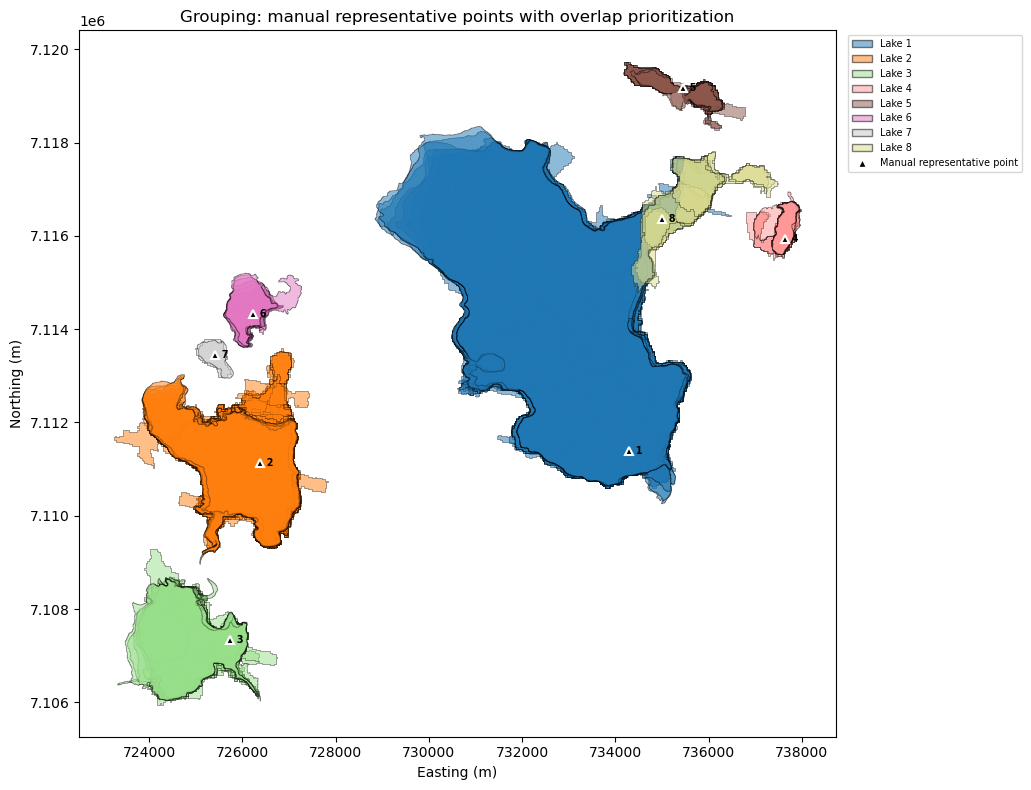

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_manual_overlap["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes_manual_overlap[all_lakes_manual_overlap["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

# Overlay manual representative points
repr_pts_manual_proj = repr_pts_manual.set_index("lake_id")
for j, lid in enumerate(lake_ids_all):
    if lid not in repr_pts_manual_proj.index:
        continue  # skip outlier IDs that have no manual point
    pt = repr_pts_manual_proj.loc[lid, "geometry"]
    ax.plot(pt.x, pt.y, marker="^", markersize=6, markeredgewidth=1.5,
            markerfacecolor="black", markeredgecolor="white", zorder=5)
    ax.annotate(f"  {lid}", (pt.x, pt.y), fontsize=7, va="center",
                color="black", fontweight="bold")

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
legend_handles.append(
    plt.Line2D([0], [0], marker="^", color="black", linestyle="None",
               markersize=6, markerfacecolor="black", markeredgecolor="white",
               label="Manual representative point")
)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: manual representative points with overlap prioritization")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig('../data/output/lake_ids_manual_repr_overlap.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach works better with our inconsistent outlines, and has the same outcome as the first overlap or proximity method. However, with this method, lakes that once become one will always be assigned as one lake, so if lakes split in reality, this method is not ideal.

### 1.5 Prepare per-lake, per-year geometry

Because each `.gpkg` can contain **multiple polygons** (one per lake), we now have a long-format GeoDataFrame
with one row per (`id`, `year_ts`) combination.

If the same lake id appears more than once in a single year (e.g. fragmented polygons),
we union them into a single geometry per (`id`, `year_ts`).

In [56]:
# Union polygons with the same id within the same year, then reset index
outlines = (
    all_lakes_prox
    .groupby(["id", "year_ts"], as_index=False)
    .agg(
        geometry=("geometry", lambda g: unary_union(g)),
        area_m2=("area_m2", "sum"),      # sum fragmented-polygon areas
    )
)
outlines = gpd.GeoDataFrame(outlines, geometry="geometry", crs=all_lakes.crs)
outlines["geometry"] = outlines["geometry"].make_valid()

print(f"Rows after aggregation: {len(outlines)}  (expected: n_lakes × n_years)")
print(outlines.head())

Rows after aggregation: 176  (expected: n_lakes × n_years)
   id  year_ts                                           geometry    area_m2
0   1     1985  POLYGON ((735450 7117050, 735450 7116870, 7354...   947700.0
1   1     1986  POLYGON ((736080 7117830, 736080 7117800, 7360...  2501100.0
2   1     1988  MULTIPOLYGON (((735000 7116630, 735000 7116600...  1362600.0
3   1     1991  POLYGON ((736770 7117530, 736770 7117500, 7367...   287100.0
4   1     1992  POLYGON ((735390 7117140, 735390 7117110, 7353...   466200.0


### 1.6 Check for missing (lake, year) combinations

Not every lake may be present in every year. The VDC needs a fully populated grid,
so we identify gaps and fill them with `None` geometries.

In [57]:
lake_ids = sorted(outlines["id"].unique())
year_list = sorted(outlines["year_ts"].unique())

# Full grid of (id, year) combinations
full_index = pd.MultiIndex.from_product([lake_ids, year_list], names=["id", "year_ts"])
current_index = pd.MultiIndex.from_frame(outlines[["id", "year_ts"]])
missing = full_index.difference(current_index)

if len(missing) == 0:
    print("No missing (lake, year) combinations — grid is complete.")
else:
    print(f"Missing combinations: {len(missing)}")
    print(missing.to_frame(index=False).to_string())
    # Fill missing rows with None geometry
    fill_rows = pd.DataFrame(
        [{"id": i, "year_ts": y, "geometry": None, "area_m2": np.nan} for i, y in missing],
    )
    fill_gdf = gpd.GeoDataFrame(fill_rows, geometry="geometry", crs=outlines.crs)
    outlines = pd.concat([outlines, fill_gdf], ignore_index=True)
    outlines = gpd.GeoDataFrame(outlines, geometry="geometry", crs=all_lakes_prox.crs)
    outlines = outlines.sort_values(["id", "year_ts"]).reset_index(drop=True)
    print("\nFilled missing entries with None geometry.")

Missing combinations: 128
     id  year_ts
0     1     1987
1     1     1989
2     1     1990
3     1     1994
4     1     1995
5     1     1996
6     1     1997
7     1     1998
8     1     1999
9     1     2000
10    1     2001
11    1     2002
12    1     2004
13    1     2005
14    1     2006
15    1     2007
16    1     2010
17    1     2011
18    1     2012
19    1     2013
20    1     2014
21    1     2015
22    1     2016
23    1     2017
24    1     2018
25    1     2019
26    1     2020
27    1     2021
28    1     2022
29    1     2023
30    1     2024
31    1     2025
32    2     1986
33    2     1987
34    2     1990
35    2     1992
36    2     1993
37    2     2007
38    2     2011
39    3     1991
40    3     2022
41    5     1989
42    5     1990
43    5     1992
44    5     1993
45    5     2000
46    5     2011
47    6     1985
48    6     1987
49    6     1991
50    6     1992
51    6     1993
52    6     1999
53    6     2000
54    6     2002
55    6     2006
56   

## 2. VDC creation

### 2.1 Compute summary geometries (one per lake)

In the lava-flow example there was a single feature, so the `geom_sum` dimension had size 1.
Here we have **one summary geometry per lake** — we use the centroid of the union of all its yearly outlines.

In [58]:
# Summary geometry per lake: centroid of the union of all yearly polygons
summary_geoms = (
    outlines.dropna(subset=["geometry"])   # ignore missing-year rows
    .groupby("id")["geometry"]
    .apply(lambda g: unary_union(g))
)
summary_geoms = gpd.GeoSeries(summary_geoms, crs=all_lakes.crs)

print("Summary geometries per lake:")
print(summary_geoms)

Summary geometries (centroids) per lake:
id
1    POINT (735496.473 7116638.817)
2    POINT (737413.589 7116181.994)
3    POINT (732660.429 7114663.695)
4    POINT (725804.935 7111354.795)
5    POINT (724784.193 7107346.814)
6      POINT (735475.227 7119067.2)
7    POINT (726296.869 7114509.705)
8    POINT (725416.678 7113413.744)
Name: geometry, dtype: geometry


### 2.2 Array format VDC

The data array has shape **(n_lakes × n_years)** where:
- `geom_sum` dimension = one centroid per lake (size = number of unique lakes)
- `year` dimension = one entry per year

Each cell contains the changing polygon geometry of that lake in that year.

In [59]:
# Build a 2-D array: rows = lakes (ordered by id), cols = years
geom_matrix = np.empty((len(lake_ids), len(year_list)), dtype=object)

for i, lid in enumerate(lake_ids):
    for j, yr in enumerate(year_list):
        row = outlines[(outlines["id"] == lid) & (outlines["year_ts"] == yr)]
        if len(row) == 0 or row.iloc[0].geometry is None:
            geom_matrix[i, j] = None
        else:
            geom_matrix[i, j] = row.iloc[0].geometry

# Summary geometry list in the same order as lake_ids
union_list = [unary_union(temporal_face[temporal_face["id"] == lid]["geometry"].dropna())
    for lid in lake_ids]

# EPSG code as integer for xvec
crs_epsg = all_lakes.crs.to_epsg()

# Build the xarray DataArray
cube_arr = xr.DataArray(
    data=geom_matrix,
    dims=["geom_sum", "year"],
    coords={
        "geom_sum": union_list,
        "year": year_list,
    },
    name="geometry",
).xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

print(cube_arr)

<xarray.DataArray 'geometry' (geom_sum: 8, year: 38)> Size: 2kB
array([[<POLYGON ((735450 7117050, 735450 7116870, 735420 7116870, 735420 7116810, 7...>,
        <POLYGON ((736080 7117830, 736080 7117800, 736050 7117800, 736050 7117770, 7...>,
        None,
        <MULTIPOLYGON (((735000 7116630, 735000 7116600, 735030 7116600, 735030 7116...>,
        None, None,
        <POLYGON ((736770 7117530, 736770 7117500, 736740 7117500, 736740 7117470, 7...>,
        <POLYGON ((735390 7117140, 735390 7117110, 735360 7117110, 735360 7116990, 7...>,
        <POLYGON ((735300 7117710, 735300 7117680, 735240 7117680, 735240 7117650, 7...>,
        None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None],
       [<POLYGON ((737100 7116540, 737100 7116510, 737070 7116510, 737070 7116480, 7...>,
        None, None,
        <POLYGON ((737070 7116510, 737070 7116480, 73

### 2.3 Add `area_m2` as a second data variable

The VDC can carry multiple variables. Here we attach the measured `area_m2`
as an additional coordinate/variable alongside the geometry.
This turns the structure into an `xr.Dataset` (≈ a multi-variable cube).

In [60]:
# Build area array WITHOUT setting a geometry index
area_matrix = np.full((len(lake_ids), len(year_list)), np.nan)

# Fill with values
for i, lid in enumerate(lake_ids):
    for j, yr in enumerate(year_list):
        row = outlines[(outlines["id"] == lid) & (outlines["year_ts"] == yr)]
        if len(row) > 0 and not pd.isna(row.iloc[0]["area_m2"]):
            area_matrix[i, j] = row.iloc[0]["area_m2"]

area_arr = xr.DataArray(
    data=area_matrix,
    dims=["geom_sum", "year"],
    coords={
        "geom_sum": union_list,
        "year": year_list,
    },
    name="area_m2",
)

# Rebuild cube_arr WITHOUT geometry index first
cube_arr_plain = xr.DataArray(
    data=geom_matrix,
    dims=["geom_sum", "year"],
    coords={
        "geom_sum": union_list,
        "year": year_list,
    },
    name="geometry",
)

# Combine into Dataset first, then set geometry index once
cube_ds = xr.Dataset({"geometry": cube_arr_plain, "area_m2": area_arr})
cube_ds = cube_ds.xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

# Keep indexed cube_arr separately if needed downstream
cube_arr = cube_arr_plain.xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

print(cube_ds)

<xarray.Dataset> Size: 5kB
Dimensions:   (geom_sum: 8, year: 38)
Coordinates:
  * geom_sum  (geom_sum) object 64B POINT (735496.4726918075 7116638.81664499...
  * year      (year) int64 304B 1985 1986 1987 1988 1989 ... 2022 2023 2024 2025
Data variables:
    geometry  (geom_sum, year) object 2kB POLYGON ((735450 7117050, 735450 71...
    area_m2   (geom_sum, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    geom_sum  GeometryIndex (crs=EPSG:32627)


### 2.4 Tabular format VDC (spatial + temporal faces)

Mirrors the cubble `face_spatial` / `face_temporal` pattern from the original notebook.

In [61]:
# Spatial face: one row per lake, with its summary (centroid) geometry
spatial_face = gpd.GeoDataFrame(
    {
        "id": lake_ids,
        "geom_sum": union_list,
    },
    geometry="geom_sum",
    crs=all_lakes.crs,
)

# Temporal face: one row per (lake_id, year) with changing geometry + attributes
temporal_face = outlines[["id", "year_ts", "area_m2", "geometry"]].copy()
temporal_face = gpd.GeoDataFrame(temporal_face, geometry="geometry", crs=all_lakes.crs)

print("=== Spatial face ===")
print(spatial_face)
print("\n=== Temporal face (first 15 rows) ===")
print(temporal_face.head(15).to_string())

=== Spatial face ===
   id                        geom_sum
0   1  POINT (735496.473 7116638.817)
1   2  POINT (737413.589 7116181.994)
2   3  POINT (732660.429 7114663.695)
3   4  POINT (725804.935 7111354.795)
4   5  POINT (724784.193 7107346.814)
5   6    POINT (735475.227 7119067.2)
6   7  POINT (726296.869 7114509.705)
7   8  POINT (725416.678 7113413.744)

=== Temporal face (first 15 rows) ===
    id  year_ts    area_m2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [62]:
print(temporal_face)

     id  year_ts    area_m2                                           geometry
0     1     1985   947700.0  POLYGON ((735450 7117050, 735450 7116870, 7354...
1     1     1986  2501100.0  POLYGON ((736080 7117830, 736080 7117800, 7360...
2     1     1987        NaN                                               None
3     1     1988  1362600.0  MULTIPOLYGON (((735000 7116630, 735000 7116600...
4     1     1989        NaN                                               None
..   ..      ...        ...                                                ...
299   8     2021        NaN                                               None
300   8     2022        NaN                                               None
301   8     2023        NaN                                               None
302   8     2024        NaN                                               None
303   8     2025        NaN                                               None

[304 rows x 4 columns]


In [63]:
print(cube_arr)

<xarray.DataArray 'geometry' (geom_sum: 8, year: 38)> Size: 2kB
array([[<POLYGON ((735450 7117050, 735450 7116870, 735420 7116870, 735420 7116810, 7...>,
        <POLYGON ((736080 7117830, 736080 7117800, 736050 7117800, 736050 7117770, 7...>,
        None,
        <MULTIPOLYGON (((735000 7116630, 735000 7116600, 735030 7116600, 735030 7116...>,
        None, None,
        <POLYGON ((736770 7117530, 736770 7117500, 736740 7117500, 736740 7117470, 7...>,
        <POLYGON ((735390 7117140, 735390 7117110, 735360 7117110, 735360 7116990, 7...>,
        <POLYGON ((735300 7117710, 735300 7117680, 735240 7117680, 735240 7117650, 7...>,
        None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None],
       [<POLYGON ((737100 7116540, 737100 7116510, 737070 7116510, 737070 7116480, 7...>,
        None, None,
        <POLYGON ((737070 7116510, 737070 7116480, 73

## 3. Exploration and analysis

### 3.1 Select a single lake from the cube

In [64]:
# Example: select the first lake by position
lake_slice = cube_arr.isel(geom_sum=0)
print(f"Lake ID: {lake_ids[3]}")
print(lake_slice)

Lake ID: 4
<xarray.DataArray 'geometry' (year: 38)> Size: 304B
array([<POLYGON ((735450 7117050, 735450 7116870, 735420 7116870, 735420 7116810, 7...>,
       <POLYGON ((736080 7117830, 736080 7117800, 736050 7117800, 736050 7117770, 7...>,
       None,
       <MULTIPOLYGON (((735000 7116630, 735000 7116600, 735030 7116600, 735030 7116...>,
       None, None,
       <POLYGON ((736770 7117530, 736770 7117500, 736740 7117500, 736740 7117470, 7...>,
       <POLYGON ((735390 7117140, 735390 7117110, 735360 7117110, 735360 7116990, 7...>,
       <POLYGON ((735300 7117710, 735300 7117680, 735240 7117680, 735240 7117650, 7...>,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None], dtype=object)
Coordinates:
  * year      (year) int64 304B 1985 1986 1987 1988 1989 ... 2022 2023 2024 2025
    geom_sum  object 8B POINT (735496.4726918075 7116638.816644994)

### 3.2 Area time series per lake

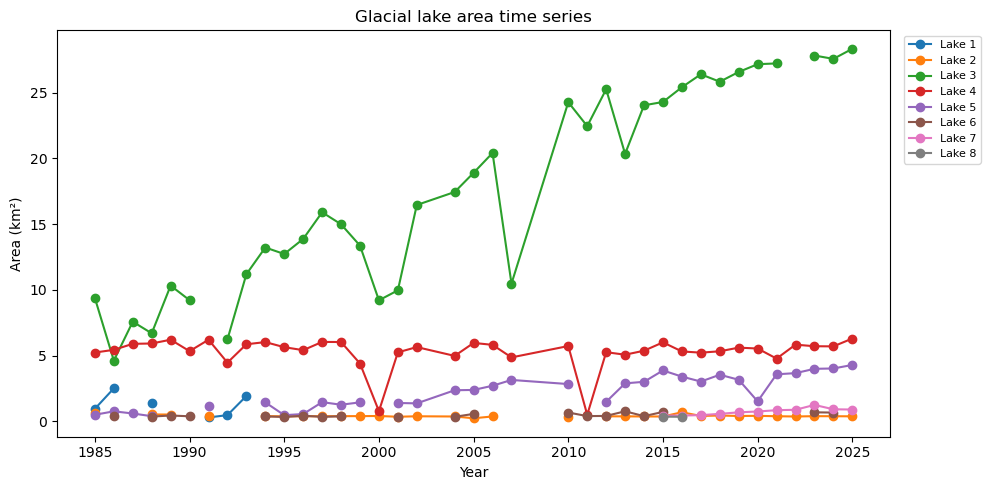

In [65]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, lid in enumerate(lake_ids):
    subset = temporal_face[temporal_face["id"] == lid].sort_values("year_ts")
    ax.plot(
        subset["year_ts"],
        subset["area_m2"] / 1e6,  # convert to km²
        marker="o",
        label=f"Lake {lid}",
    )

ax.set_xlabel("Year")
ax.set_ylabel("Area (km²)")
ax.set_title("Glacial lake area time series")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig('../data/output/glacial_lake_area_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

### 3.3 Total lake area per year

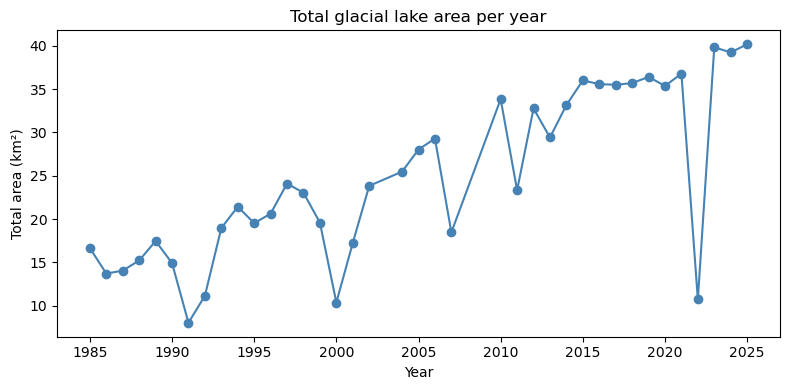

year_ts
1985    16.648200
1986    13.703400
1987    14.051700
1988    15.219900
1989    17.465400
1990    14.914800
1991     8.026200
1992    11.151900
1993    18.963900
1994    21.428100
1995    19.518300
1996    20.623500
1997    24.098400
1998    23.030100
1999    19.578600
2000    10.365300
2001    17.249400
2002    23.830200
2004    25.467300
2005    28.025100
2006    29.283300
2007    18.465300
2010    33.831900
2011    23.328900
2012    32.763600
2013    29.411100
2014    33.152400
2015    35.997300
2016    35.571765
2017    35.495827
2018    35.685670
2019    36.404239
2020    35.359337
2021    36.777915
2022    10.719706
2023    39.822581
2024    39.228956
2025    40.170898
Name: area_m2, dtype: float64


In [66]:
total_area = (
    temporal_face.groupby("year_ts")["area_m2"]
    .sum()
    / 1e6  # km²
)

fig, ax = plt.subplots(figsize=(8, 4))
total_area.plot(ax=ax, marker="o", color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Total area (km²)")
ax.set_title("Total glacial lake area per year")
plt.tight_layout()
plt.savefig('../data/output/glacial_lake_total_area.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

print(total_area)

### 3.4 Save the VDC Dataset

Geometry variables are stored as WKT before writing to NetCDF (xarray cannot serialise Shapely objects natively).

In [67]:
# Convert geometry cells and index to WKT for serialisation
wkt_geoms = np.vectorize(
    lambda g: to_wkt(g) if g is not None else ""
)(geom_matrix)

wkt_unions = [to_wkt(c) for c in union_list]

ds_nc = xr.Dataset(
    {
        "geometry_wkt": xr.DataArray(
            wkt_geoms,
            dims=["lake_id", "year"],
            coords={"lake_id": lake_ids, "year": year_list},
        ),
        "area_m2": xr.DataArray(
            area_matrix,
            dims=["lake_id", "year"],
            coords={"lake_id": lake_ids, "year": year_list},
        ),
        "union_wkt": xr.DataArray(
            wkt_unions,
            dims=["lake_id"],
            coords={"lake_id": lake_ids},
        ),
    }
)
ds_nc.attrs["crs"] = str(all_lakes.crs)
ds_nc.attrs["description"] = "Glacial lake VDC — geometry stored as WKT"

out_nc = Path("C:/Users/JULIA-PC/OneDrive - Universität Salzburg/MorphEO/morpheo/data/output/glacial_lakes_cube.nc")
ds_nc.to_netcdf(out_nc)
print(f"VDC saved to {out_nc}")

VDC saved to C:\Users\b1120440\morpheo\glacial_lakes_cube.nc


In [68]:
print(temporal_face.geometry.total_bounds)  # minx, miny, maxx, maxy
print(f"X range: {temporal_face.geometry.total_bounds[2] - temporal_face.geometry.total_bounds[0]:.0f} m")
print(f"Y range: {temporal_face.geometry.total_bounds[3] - temporal_face.geometry.total_bounds[1]:.0f} m")


[ 723240.         7105950.          737994.89289625 7119720.        ]
X range: 14755 m
Y range: 13770 m


C:\Users\b1120440\AppData\Local\Temp\ipykernel_13832\113095622.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_lakes = cm.get_cmap("tab20", len(lake_ids_sorted))


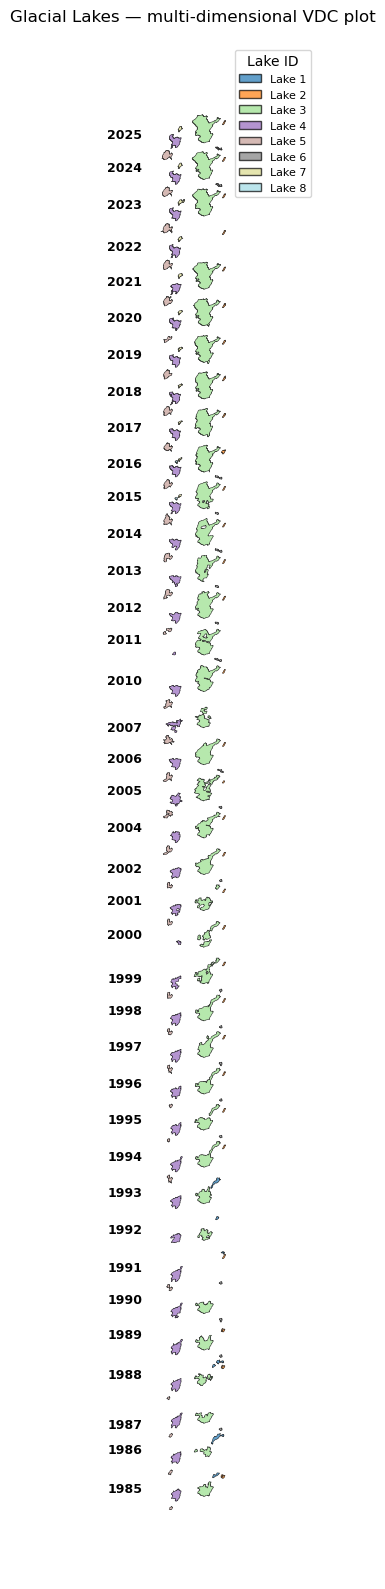

In [69]:
# --- Shear parameters (adjust to taste) ---
a, b_, d, e = 1.0, 0.3, 0.0, 1.0

# Vertical spacing between years (in CRS units = metres)
# Increase if polygons overlap, decrease if too spread out
Y_SPACING = 10_000

all_years = sorted(temporal_face["year_ts"].unique())
year_to_idx = {yr: i + 1 for i, yr in enumerate(all_years)}

# --- Apply shear + vertical shift to each polygon ---
lakes_shear = []
for _, row in temporal_face.iterrows():
    if row["geometry"] is None or row.geometry.is_empty:
        continue
    geom = row["geometry"]
    # Apply shear
    geom_s = affine_transform(geom, [a, b_, d, e, 0, 0])
    # Shift vertically by year index
    shift_y = year_to_idx[row["year_ts"]] * Y_SPACING
    geom_shifted = affine_transform(geom_s, [1, 0, 0, 1, 0, shift_y])
    lakes_shear.append({
        "id": row["id"],
        "year_ts": row["year_ts"],
        "geometry": geom_shifted,
    })

lakes_shear_gdf = gpd.GeoDataFrame(lakes_shear, geometry="geometry")

# --- Colour mapping: one colour per lake ID ---
lake_ids_sorted = sorted(lakes_shear_gdf["id"].unique())
cmap_lakes = cm.get_cmap("tab20", len(lake_ids_sorted))
id_to_color = {lid: cmap_lakes(i) for i, lid in enumerate(lake_ids_sorted)}

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 16))

for _, row in lakes_shear_gdf.iterrows():
    color = id_to_color[row["id"]]
    gpd.GeoSeries([row["geometry"]]).plot(
        ax=ax, facecolor=color, edgecolor="black", linewidth=0.4, alpha=0.7
    )

# --- Year labels on the left ---
# Place label at the vertical centre of each year's polygons
for yr in all_years:
    sub = lakes_shear_gdf[lakes_shear_gdf["year_ts"] == yr]
    if sub.empty:
        continue
    y_label = sub["geometry"].centroid.y.mean()
    x_label = lakes_shear_gdf["geometry"].bounds["minx"].min() - 5_000
    ax.text(x_label, y_label, str(yr), fontsize=9, va="center", ha="right", fontweight="bold")

# --- Legend for lake IDs ---
legend_handles = [
    Patch(facecolor=id_to_color[lid], edgecolor="k", alpha=0.7, label=f"Lake {lid}")
    for lid in lake_ids_sorted
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Lake ID")

ax.set_title("Glacial Lakes — multi-dimensional VDC plot")
ax.axis("off")
plt.tight_layout()
plt.savefig('../data/output/glacial_lakes_VDC_plot_prox.png', bbox_inches='tight', dpi=150, pad_inches=0)
plt.show()
plt.close()

### Comparing summary geometries methods

In [72]:
def build_vdc(outlines, lake_ids, year_list, geom_sum_list, crs_epsg, name="vdc"):
    """
    Build a VDC dataset and spatial/temporal face for a given geom_sum type.
    
    Parameters
    ----------
    outlines : GeoDataFrame — per-lake, per-year geometries (from section 1.5)
    lake_ids : list of lake IDs in order
    year_list : list of years in order
    geom_sum_list : list of summary geometries, one per lake, same order as lake_ids
    crs_epsg : int — EPSG code
    name : str — label for printing
    """
    geom_matrix = np.empty((len(lake_ids), len(year_list)), dtype=object)
    area_matrix = np.full((len(lake_ids), len(year_list)), np.nan)

    for i, lid in enumerate(lake_ids):
        for j, yr in enumerate(year_list):
            row = outlines[(outlines["id"] == lid) & (outlines["year_ts"] == yr)]
            if len(row) == 0 or row.iloc[0].geometry is None:
                geom_matrix[i, j] = None
            else:
                geom_matrix[i, j] = row.iloc[0].geometry
                area_matrix[i, j] = row.iloc[0]["area_m2"]

    cube_ds = xr.Dataset({
        "geometry": xr.DataArray(geom_matrix, dims=["geom_sum", "year"],
                                 coords={"geom_sum": geom_sum_list, "year": year_list}),
        "area_m2": xr.DataArray(area_matrix, dims=["geom_sum", "year"],
                                coords={"geom_sum": geom_sum_list, "year": year_list}),
    }).xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

    spatial_face = gpd.GeoDataFrame(
        {"id": lake_ids, "geom_sum": geom_sum_list},
        geometry="geom_sum", crs=outlines.crs
    )
    temporal_face = gpd.GeoDataFrame(
        outlines[["id", "year_ts", "area_m2", "geometry"]].copy(),
        geometry="geometry", crs=outlines.crs
    )

    print(f"\n=== VDC: {name} ===")
    print(cube_ds)
    return cube_ds, spatial_face, temporal_face

In [ ]:
# a) union/dissolve polygon itself
union_list = [
    unary_union(outlines.dropna(subset=["geometry"])[outlines["id"] == lid]["geometry"])
    for lid in lake_ids
]

# b) centroid of union 
centroid_list = [
    unary_union(outlines.dropna(subset=["geometry"])[outlines["id"] == lid]["geometry"]).centroid
    for lid in lake_ids
]

# c) bounding box of union
bbox_list = [
    unary_union(outlines.dropna(subset=["geometry"])[outlines["id"] == lid]["geometry"]).envelope
    for lid in lake_ids
]

# d) representative point of union (Shapely)
repr_list = [
    unary_union(outlines.dropna(subset=["geometry"])[outlines["id"] == lid]["geometry"]).representative_point()
    for lid in lake_ids
]

# e) manual representative point
repr_pts_idx = repr_pts_manual.set_index("lake_id")
manual_list = [repr_pts_idx.loc[lid, "geometry"] for lid in lake_ids]
import warnings
warnings.simplefilter("ignore", UserWarning)

In [74]:
cube_union,    sf_union,    tf = build_vdc(outlines, lake_ids, year_list, union_list,    crs_epsg, name="union")
cube_centroid, sf_centroid, tf = build_vdc(outlines, lake_ids, year_list, centroid_list, crs_epsg, name="centroid")
cube_bbox,     sf_bbox,     tf = build_vdc(outlines, lake_ids, year_list, bbox_list,     crs_epsg, name="bbox")
cube_repr,     sf_repr,     tf = build_vdc(outlines, lake_ids, year_list, repr_list,     crs_epsg, name="repr_point")
cube_manual,   sf_manual,   tf = build_vdc(outlines, lake_ids, year_list, manual_list,   crs_epsg, name="manual_repr")


=== VDC: union ===
<xarray.Dataset> Size: 5kB
Dimensions:   (geom_sum: 8, year: 38)
Coordinates:
  * geom_sum  (geom_sum) object 64B POLYGON ((735300 7116120, 735270 7116120,...
  * year      (year) int64 304B 1985 1986 1987 1988 1989 ... 2022 2023 2024 2025
Data variables:
    geometry  (geom_sum, year) object 2kB POLYGON ((735450 7117050, 735450 71...
    area_m2   (geom_sum, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    geom_sum  GeometryIndex (crs=EPSG:32627)

=== VDC: centroid ===
<xarray.Dataset> Size: 5kB
Dimensions:   (geom_sum: 8, year: 38)
Coordinates:
  * geom_sum  (geom_sum) object 64B POINT (735496.4726918075 7116638.81664499...
  * year      (year) int64 304B 1985 1986 1987 1988 1989 ... 2022 2023 2024 2025
Data variables:
    geometry  (geom_sum, year) object 2kB POLYGON ((735450 7117050, 735450 71...
    area_m2   (geom_sum, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    geom_sum  GeometryIndex (crs=EPSG:32627)

=== VDC: bbox ==

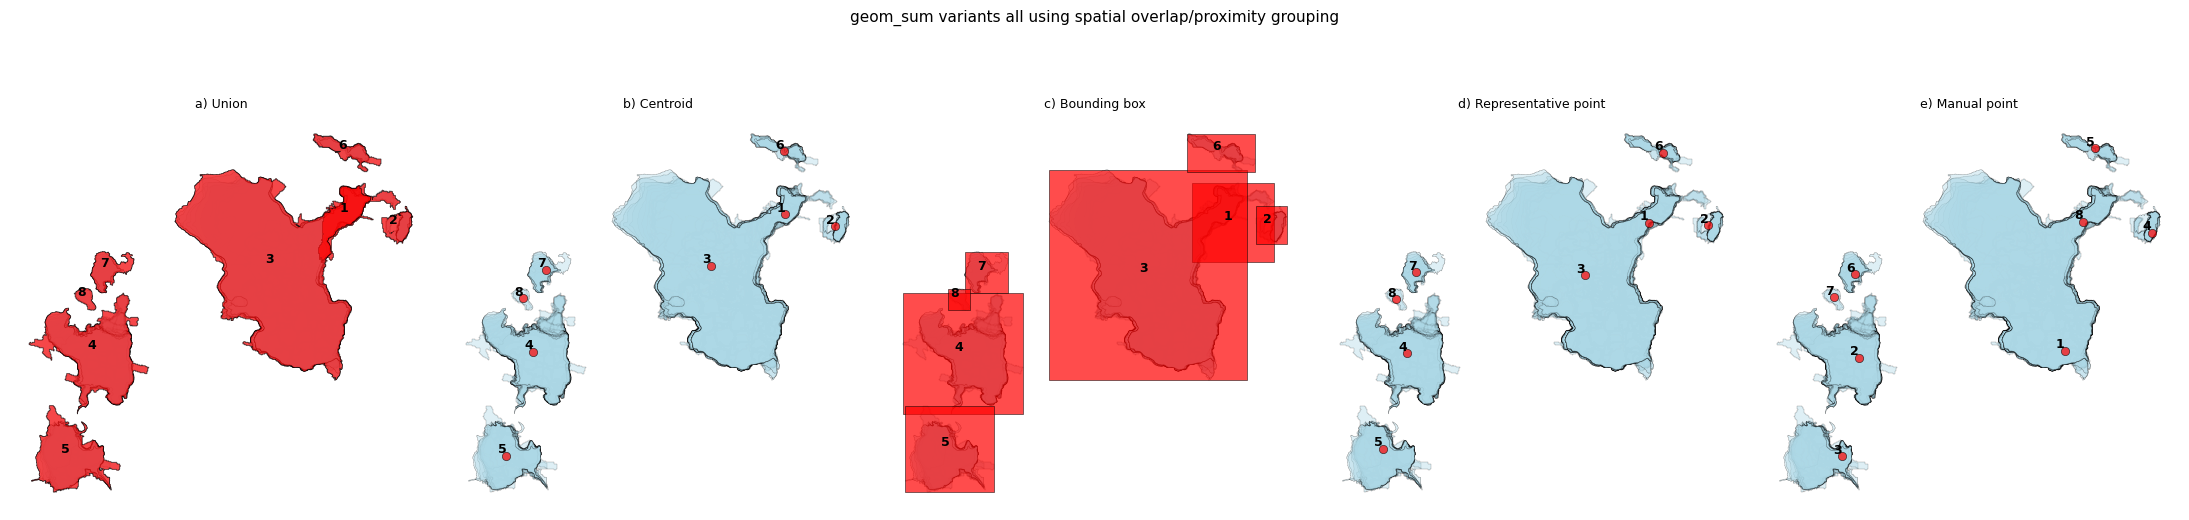

In [134]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
configs = [
    (sf_union,    "a) Union",               False),
    (sf_centroid, "b) Centroid",            True),
    (sf_bbox,     "c) Bounding box",        False),
    (sf_repr,     "d) Representative point",True),
    (sf_manual,   "e) Manual point",        True),
]
for ax, (sf, title, is_point) in zip(axes, configs):
    temporal_face.plot(ax=ax, color="lightblue", edgecolor="k", linewidth=0.3, alpha=0.4)
    sf.plot(ax=ax, color="red", edgecolor="k", linewidth=0.5, alpha=0.7)
    
    # Add lake IDs
    for _, row in sf.iterrows():
        geom = row["geom_sum"]
        pt = geom.centroid if geom.geom_type in ("Polygon", "MultiPolygon") else geom
        ax.annotate(str(row["id"]), xy=(pt.x, pt.y), fontsize=9, fontweight="bold",
                    ha="right", va="bottom", color="black",)
    
    ax.set_title(title, fontsize=9)
    ax.set_axis_off()
plt.suptitle("geom_sum variants all using spatial overlap/proximity grouping", fontsize=11)
plt.tight_layout()
plt.savefig('../data/output/geom_sum_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

#### Answering the question: To which lake does this point belong to?

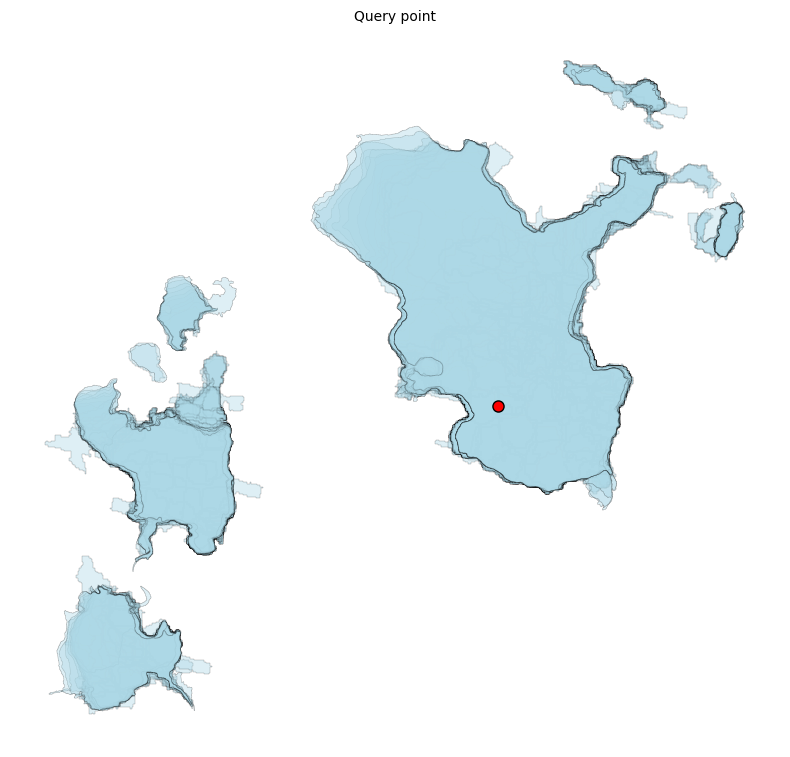

union      → lake ID(s): [3]
centroid   → no match
bbox       → lake ID(s): [3]
repr       → no match
manual     → no match


In [106]:
# A point in the lower half of Jokulsarlon
query_point = Point(732788, 7112440) 

# plot the point
fig, ax = plt.subplots(figsize=(8, 8))
temporal_face.plot(ax=ax, color="lightblue", edgecolor="k", linewidth=0.3, alpha=0.4)
ax.plot(query_point.x, query_point.y, marker="o", markersize=8,
        markerfacecolor="red", markeredgecolor="black", markeredgewidth=1, zorder=5)
ax.set_axis_off()
ax.set_title("Query point", fontsize=10)
plt.tight_layout()
plt.show()

# For each geom_sum variant, which lake does this point fall in?
for name, sf in [("union", sf_union), ("centroid", sf_centroid),
                 ("bbox", sf_bbox), ("repr", sf_repr), ("manual", sf_manual)]:
    match = sf[sf.contains(query_point)]
    if match.empty:
        print(f"{name:10s} → no match")
    else:
        print(f"{name:10s} → lake ID(s): {list(match['id'])}")

The point query answer should be Jokulsarlon (lake 3 for most methods, lake 1 for manual). Union and bbox were correct, and the point based ones said no match, since the point was not at the exact points.

#### Answering the question: Which lakes fall within this polygon?

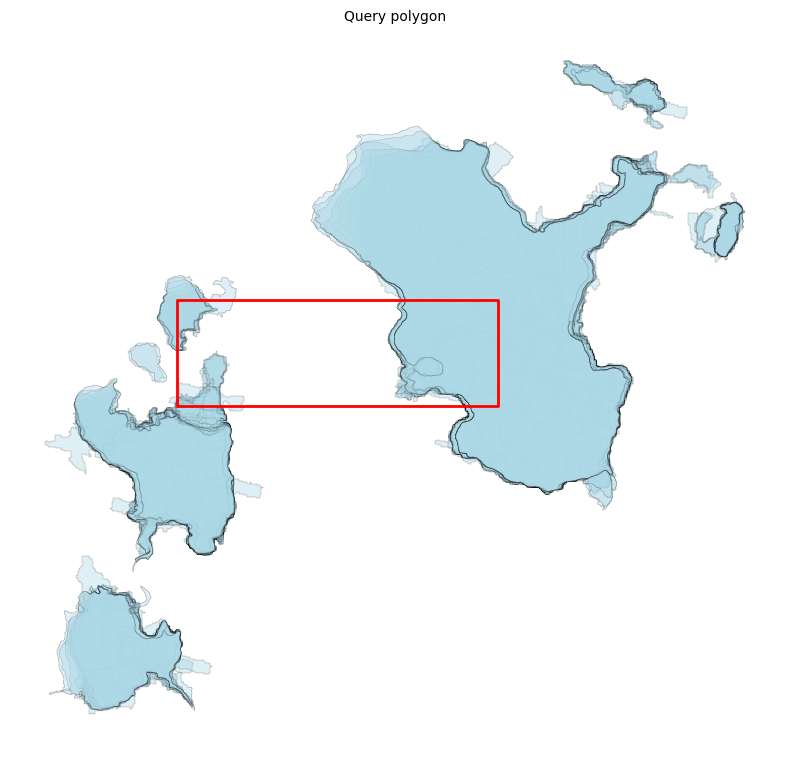

union      → lakes within polygon: [3, 4, 7]
centroid   → lakes within polygon: [3, 7]
bbox       → lakes within polygon: [3, 4, 7]
repr       → lakes within polygon: [3, 7]
manual     → lakes within polygon: [6]


In [107]:
# A polygon covering the eastern part of Breidarlon and western part of Vatnajökull
study_area = box(726020, 7114689, 732788, 7112440)  

# plot hte polygon
fig, ax = plt.subplots(figsize=(8, 8))
temporal_face.plot(ax=ax, color="lightblue", edgecolor="k", linewidth=0.3, alpha=0.4)
gpd.GeoSeries([study_area], crs=temporal_face.crs).plot(
    ax=ax, facecolor="none", edgecolor="red", linewidth=2, zorder=5)
ax.set_axis_off()
ax.set_title("Query polygon", fontsize=10)
plt.tight_layout()
plt.show()

for name, sf in [("union", sf_union), ("centroid", sf_centroid),
                 ("bbox", sf_bbox), ("repr", sf_repr), ("manual", sf_manual)]:
    match = sf[sf.intersects(study_area)]
    print(f"{name:10s} → lakes within polygon: {sorted(match['id'].tolist())}")

The polygon query answer should be lakes 3, 4, and 7 (1, 2, and 6 for manual). Union and dissolve and bbox were correct again, and point based only identified the lakes which points fell within the polygon. Lake 4 (lake 2 for manual) matched with the old outlines, as the most recent outlines do not fall wihtin the polygon. Is this a good thing? When we query, do we want to find lake outlines from any time that are inside the polygon, or are we only interested in current outlines?

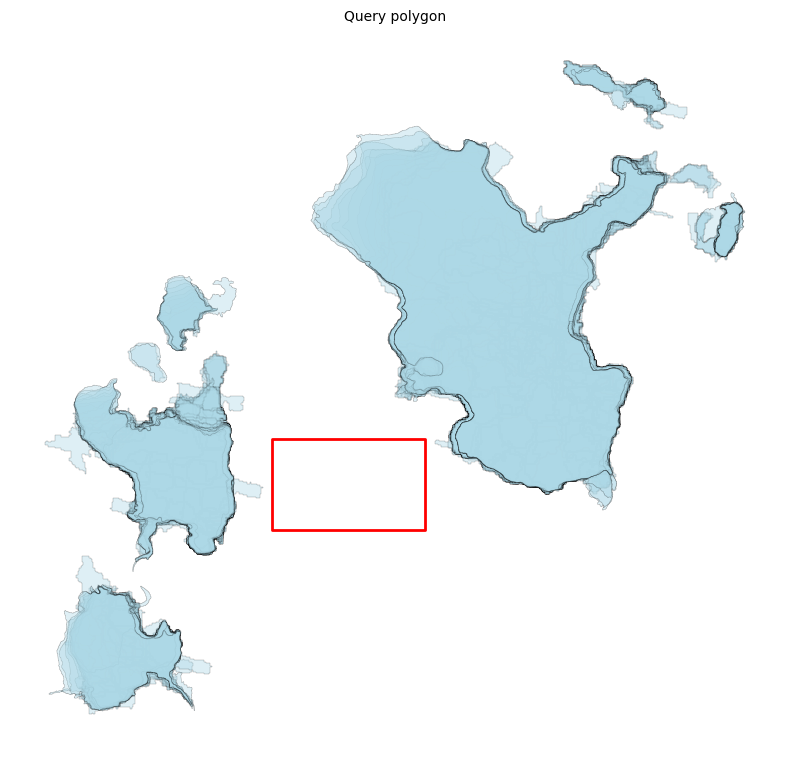

union      → lakes within polygon: []
centroid   → lakes within polygon: []
bbox       → lakes within polygon: [3]
repr       → lakes within polygon: []
manual     → lakes within polygon: []


In [111]:
# A polygon covering the eastern part of Breidarlon and western part of Vatnajökull
study_area = box(728018, 7111762, 731242, 7109828)  

# plot hte polygon
fig, ax = plt.subplots(figsize=(8, 8))
temporal_face.plot(ax=ax, color="lightblue", edgecolor="k", linewidth=0.3, alpha=0.4)
gpd.GeoSeries([study_area], crs=temporal_face.crs).plot(
    ax=ax, facecolor="none", edgecolor="red", linewidth=2, zorder=5)
ax.set_axis_off()
ax.set_title("Query polygon", fontsize=10)
plt.tight_layout()
plt.show()

for name, sf in [("union", sf_union), ("centroid", sf_centroid),
                 ("bbox", sf_bbox), ("repr", sf_repr), ("manual", sf_manual)]:
    match = sf[sf.intersects(study_area)]
    print(f"{name:10s} → lakes within polygon: {sorted(match['id'].tolist())}")

Made another polygon query in between the lakes, and as expected, the bbox still falsely gives lake 3 as the polygon is within the bounding box. Union/dissolve seems to be performing the best for our scenario.

#### Answering the question: Which lakes are within 500 m of the Vatnajökull glacier?

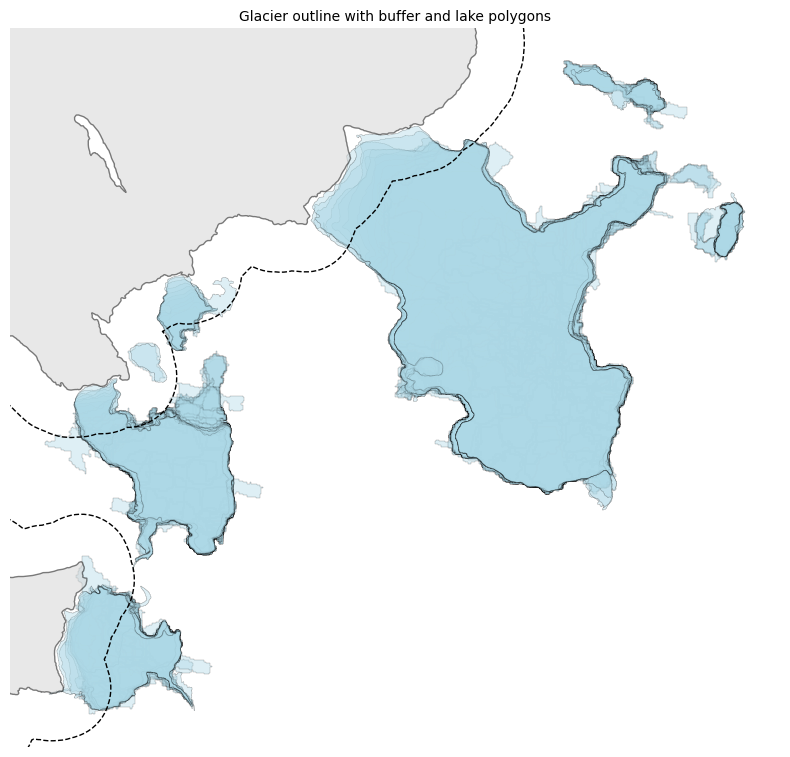

union      → lakes within distance: [3, 4, 5, 7, 8]
centroid   → lakes within distance: [7, 8]
bbox       → lakes within distance: [3, 4, 5, 7, 8]
repr       → lakes within distance: [7, 8]
manual     → lakes within distance: [6, 7]


In [171]:
glacier_margin = gpd.read_file("C:/Users/b1120440/OneDrive - Universität Salzburg/MorphEO/data/vatnajokull_outlines/glacier_2025.gpkg").to_crs(outlines.crs)

# Create a buffer around the glacier
margin_geom = glacier_margin.union_all()
BUFFER_DIST = 1000  # in meters
buffer = gpd.GeoSeries([margin_geom.buffer(BUFFER_DIST)], crs=outlines.crs)

fig, ax = plt.subplots(figsize=(8, 8))
temporal_face.plot(ax=ax, color="lightblue", edgecolor="k", linewidth=0.3, alpha=0.4)
# get the lake extent
xlim = ax.get_xlim()
ylim = ax.get_ylim()

glacier_margin.plot(ax=ax, facecolor="lightgrey", edgecolor="k", linewidth=1, alpha=0.5, zorder=2)
buffer.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1, linestyle="--")
# return lake extent
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_axis_off()
ax.set_title("Glacier outline with buffer and lake polygons", fontsize=10)
plt.tight_layout()
plt.show()

for name, sf in [("union", sf_union), ("centroid", sf_centroid),
                 ("bbox", sf_bbox), ("repr", sf_repr), ("manual", sf_manual)]:
    sf_copy = sf.copy()
    sf_copy["dist_to_margin"] = sf_copy.geometry.distance(margin_geom)
    within = sf_copy[sf_copy["dist_to_margin"] <= BUFFER_DIST]
    print(f"{name:10s} → lakes within distance: {sorted(within['id'].tolist())}")

In this query the correct answer should be five lakes; 3, 4, 5 , 7 and 8 (1, 2, 3, 6, 7 for manual). Again, dissolve and bbox are correct, while the point methods struggle. 

## 4. Vatnajökull glacier VDC

In [135]:
DATA_DIR = Path("C:/Users/b1120440/OneDrive - Universität Salzburg/MorphEO/data/vatnajokull_outlines")

# Find all annual files and sort chronologically
gpkg_files = sorted(DATA_DIR.glob("glacier_*.gpkg"))
print(f"Found {len(gpkg_files)} files:")
for f in gpkg_files:
    print(f"  {f.name}")

Found 10 files:
  glacier_1946.gpkg
  glacier_1970_1980.gpkg
  glacier_1998_2004.gpkg
  glacier_2007_2012.gpkg
  glacier_2014.gpkg
  glacier_2017.gpkg
  glacier_2019.gpkg
  glacier_2021.gpkg
  glacier_2023.gpkg
  glacier_2025.gpkg


In [136]:
def read_glacier_file(path: Path) -> gpd.GeoDataFrame:
    """
    Read a single glacier outline GeoPackage.
    Handles both single-year (glacier_2014.gpkg) and 
    multi-year (glacier_1970_1980.gpkg) filenames.
    Multi-year files are expanded to one copy per year.
    """
    gdf = gpd.read_file(path)
    gdf["source_file"] = path.name
    
    # Parse year(s) from filename
    parts = path.stem.replace("glacier_", "").split("_")
    years = list(range(int(parts[0]), int(parts[-1]) + 1)) if len(parts) > 1 else [int(parts[0])]
    
    # Duplicate the GeoDataFrame for each year it covers
    frames = []
    for yr in years:
        copy = gdf.copy()
        copy["year_ts"] = yr
        frames.append(copy)
    
    return pd.concat(frames, ignore_index=True)


# Read and concatenate all files
all_glacier = pd.concat([read_glacier_file(p) for p in gpkg_files], ignore_index=True)
all_glacier = gpd.GeoDataFrame(all_glacier, geometry="geometry")

print(all_glacier.info())
print(f"\nYears present: {sorted(all_glacier['year_ts'].unique())}")
print(f"Total rows: {len(all_glacier)}")

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            31 non-null     str           
 1   Name          0 non-null      object        
 2   description   0 non-null      object        
 3   timestamp     0 non-null      datetime64[ms]
 4   begin         0 non-null      datetime64[ms]
 5   end           0 non-null      datetime64[ms]
 6   altitudeMode  0 non-null      object        
 7   tessellate    31 non-null     int32         
 8   extrude       31 non-null     int32         
 9   visibility    31 non-null     int32         
 10  drawOrder     0 non-null      float64       
 11  icon          0 non-null      object        
 12  ogc_fid       31 non-null     int32         
 13  objectid      31 non-null     str           
 14  catagory      31 non-null     str           
 15  type          31 non-null     str 

In [137]:
def get_glacier_for_year(year: int) -> object:
    """
    Return the glacier geometry for a given year.
    Uses the nearest available year if exact match not found.
    """
    available = sorted(all_glacier["year_ts"].unique())
    
    if year in available:
        match_year = year
    else:
        # Find nearest available year
        match_year = min(available, key=lambda y: abs(y - year))
        print(f"  Year {year} not available, using {match_year}")
    
    geom = all_glacier[all_glacier["year_ts"] == match_year].union_all()
    return geom

Check for each year in the time series which lakes were within 1 km of the glacier at that time

In [143]:
results = []
for yr in year_list:
    margin_geom = get_glacier_for_year(yr)
    for name, sf in [("union", sf_union), ("centroid", sf_centroid),
                     ("bbox", sf_bbox), ("repr", sf_repr), ("manual", sf_manual)]:
        sf_copy = sf.copy()
        sf_copy["dist_to_margin"] = sf_copy.geometry.distance(margin_geom)
        within_ids = sorted(sf_copy[sf_copy["dist_to_margin"] <= 500]["id"].tolist())
        results.append({"year": yr, "geom_sum": name, "lakes_within_distance": within_ids})

df_results = pd.DataFrame(results)
print(df_results.to_string())

  Year 1985 not available, using 1980
  Year 1986 not available, using 1980
  Year 1987 not available, using 1980
  Year 1988 not available, using 1980
  Year 1989 not available, using 1980
  Year 1990 not available, using 1998
  Year 1991 not available, using 1998
  Year 1992 not available, using 1998
  Year 1993 not available, using 1998
  Year 1994 not available, using 1998
  Year 1995 not available, using 1998
  Year 1996 not available, using 1998
  Year 1997 not available, using 1998
  Year 2005 not available, using 2004
  Year 2006 not available, using 2007
  Year 2013 not available, using 2012
  Year 2015 not available, using 2014
  Year 2016 not available, using 2017
  Year 2018 not available, using 2017
  Year 2020 not available, using 2019
  Year 2022 not available, using 2021
  Year 2024 not available, using 2023
     year  geom_sum  lakes_within_distance
0    1985     union  [1, 3, 4, 5, 6, 7, 8]
1    1985  centroid     [3, 4, 5, 6, 7, 8]
2    1985      bbox  [1, 3, 4, 5, 6

In [144]:
# ── 1. Prepare glacier outlines in the same format as lake outlines ──

# all_glacier already has year_ts from read_glacier_file()
# Union any multi-polygon per year (same as lakes section 1.5)
glacier_outlines = (
    all_glacier
    .groupby("year_ts", as_index=False)
    .agg(geometry=("geometry", lambda g: unary_union(g)))
)
glacier_outlines = gpd.GeoDataFrame(glacier_outlines, geometry="geometry", crs=all_glacier.crs)
glacier_outlines["geometry"] = glacier_outlines["geometry"].make_valid()
glacier_outlines["id"] = 0          # single glacier feature, ID = 0
glacier_outlines["feature_type"] = "glacier"
glacier_outlines["area_m2"] = glacier_outlines.geometry.area

# Add feature_type to lake outlines
outlines_lakes = outlines.copy()
outlines_lakes["feature_type"] = "lake"

print(f"Glacier rows: {len(glacier_outlines)} (one per year)")
print(f"Lake rows:    {len(outlines_lakes)}")

Glacier rows: 31 (one per year)
Lake rows:    304


In [ ]:
glacier_outlines

In [145]:
# ── 2. Define combined feature list ──
# Lakes: IDs 1–8, glacier: ID 0
# Use 0 for glacier so it sorts first and is easy to filter

all_feature_ids  = [0] + lake_ids          # [0, 1, 2, 3, 4, 5, 6, 7, 8]
feature_types    = ["glacier"] + ["lake"] * len(lake_ids)

# Combined year list — union of both (should be the same 1985–2025)
combined_year_list = sorted(set(year_list) | set(glacier_outlines["year_ts"].unique()))
print(f"Combined years: {combined_year_list}")

Combined years: [np.int64(1946), np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974), np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [ ]:
# ── 3. Compute summary geometries for all features ──

# Glacier: dissolve of its temporal union
glacier_geom_sum = unary_union(glacier_outlines["geometry"])

# Lakes: dissolve of temporal union (same as before)
lake_geom_sums = [
    unary_union(outlines_lakes.dropna(subset=["geometry"])[outlines_lakes["id"] == lid]["geometry"])
    for lid in lake_ids
]

all_geom_sums = [glacier_geom_sum] + lake_geom_sums

In [147]:
# ── 4. Build combined geometry and area matrices ──

n_features = len(all_feature_ids)
n_years    = len(combined_year_list)

geom_matrix_combined = np.empty((n_features, n_years), dtype=object)
area_matrix_combined = np.full((n_features, n_years), np.nan)

for i, fid in enumerate(all_feature_ids):
    for j, yr in enumerate(combined_year_list):

        if fid == 0:
            # Glacier
            row = glacier_outlines[glacier_outlines["year_ts"] == yr]
        else:
            # Lake
            row = outlines_lakes[(outlines_lakes["id"] == fid) & (outlines_lakes["year_ts"] == yr)]

        if len(row) == 0 or row.iloc[0].geometry is None:
            geom_matrix_combined[i, j] = None
        else:
            geom_matrix_combined[i, j] = row.iloc[0].geometry
            area_matrix_combined[i, j] = row.iloc[0]["area_m2"]

In [148]:
# ── 5. Build the combined VDC Dataset ──

crs_epsg = outlines.crs.to_epsg()

cube_combined = xr.Dataset({
    "geometry": xr.DataArray(
        geom_matrix_combined,
        dims=["geom_sum", "year"],
        coords={"geom_sum": all_geom_sums, "year": combined_year_list},
    ),
    "area_m2": xr.DataArray(
        area_matrix_combined,
        dims=["geom_sum", "year"],
        coords={"geom_sum": all_geom_sums, "year": combined_year_list},
    ),
    # Extra non-geometry coordinate to label each feature
    "feature_id": xr.DataArray(all_feature_ids,   dims=["geom_sum"]),
    "feature_type": xr.DataArray(feature_types,   dims=["geom_sum"]),
}).xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

print(cube_combined)

<xarray.Dataset> Size: 8kB
Dimensions:       (geom_sum: 9, year: 53)
Coordinates:
  * geom_sum      (geom_sum) object 72B POLYGON ((764574.2439711099 7182707.8...
  * year          (year) int64 424B 1946 1970 1971 1972 ... 2022 2023 2024 2025
Data variables:
    geometry      (geom_sum, year) object 4kB MULTIPOLYGON (((745339.75802620...
    area_m2       (geom_sum, year) float64 4kB 8.338e+09 8.218e+09 ... nan nan
    feature_id    (geom_sum) int64 72B 0 1 2 3 4 5 6 7 8
    feature_type  (geom_sum) <U7 252B 'glacier' 'lake' 'lake' ... 'lake' 'lake'
Indexes:
    geom_sum  GeometryIndex (crs=EPSG:32627)


In [149]:
# ── 6. Spatial and temporal faces ──

spatial_face_combined = gpd.GeoDataFrame(
    {"id": all_feature_ids, "feature_type": feature_types, "geom_sum": all_geom_sums},
    geometry="geom_sum", crs=outlines.crs
)

temporal_face_combined = pd.concat([
    glacier_outlines[["id", "year_ts", "area_m2", "geometry", "feature_type"]],
    outlines_lakes[["id", "year_ts", "area_m2", "geometry", "feature_type"]],
], ignore_index=True)
temporal_face_combined = gpd.GeoDataFrame(temporal_face_combined, geometry="geometry", crs=outlines.crs)

print(spatial_face_combined)
print(f"\nTemporal face rows: {len(temporal_face_combined)}")

   id feature_type                                           geom_sum
0   0      glacier  POLYGON ((764574.244 7182707.836, 764728.675 7...
1   1         lake  POLYGON ((735300 7116120, 735270 7116120, 7352...
2   2         lake  POLYGON ((737610 7115520, 737580 7115520, 7375...
3   3         lake  POLYGON ((731820 7111560, 731760 7111560, 7317...
4   4         lake  POLYGON ((725910 7109910, 725910 7109880, 7258...
5   5         lake  POLYGON ((724770 7106100, 724770 7106070, 7247...
6   6         lake  POLYGON ((735120 7119420, 735150 7119420, 7351...
7   7         lake  POLYGON ((726540 7114290, 726524.54 7114290, 7...
8   8         lake  POLYGON ((725143.576 7113727.343, 725160 71137...

Temporal face rows: 335


In [ ]:
temporal_face_combined

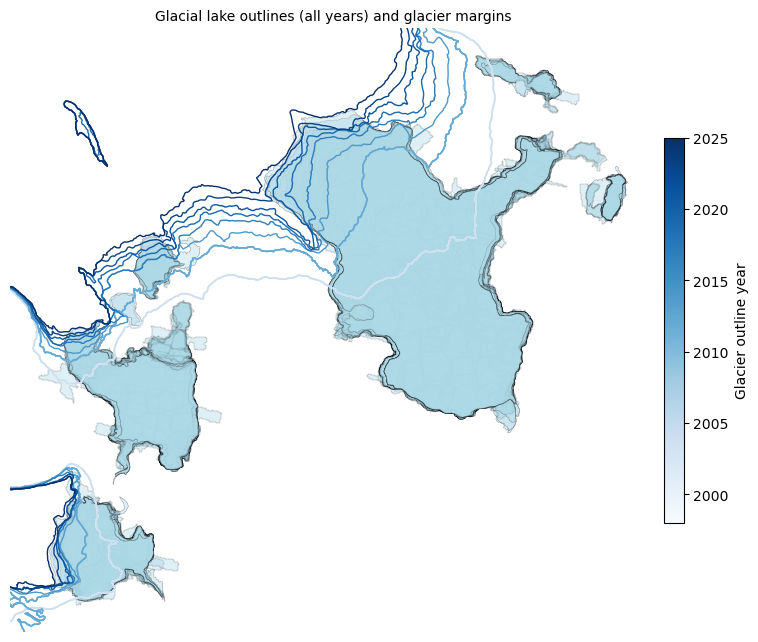

In [166]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot lake polygons (all years) to set the extent
temporal_face_combined[temporal_face_combined["feature_type"] == "lake"].plot(ax=ax, color="lightblue", edgecolor="k", linewidth=0.3, alpha=0.4)

# Lock the axis to the lake extent
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Plot all glacier outlines per year, coloured by year
years_available = temporal_face_combined[(temporal_face_combined["feature_type"] == "glacier") & (temporal_face_combined["year_ts"] >= 1985)
]["year_ts"].unique()
cmap_glacier = plt.cm.Blues
norm_glacier = mcolors.Normalize(vmin=min(years_available), vmax=max(years_available))

for yr in years_available:
    geom = temporal_face_combined[(temporal_face_combined["feature_type"] == "glacier") & (temporal_face_combined["year_ts"] == yr)]
    geom.plot(ax=ax, facecolor="none",
              edgecolor=cmap_glacier(norm_glacier(yr)),
              linewidth=1.0, zorder=3)

# Colorbar for glacier years
sm = ScalarMappable(cmap=cmap_glacier, norm=norm_glacier)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Glacier outline year", shrink=0.5, pad=0.01)

# Restore lake extent
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_axis_off()
ax.set_title("Glacial lake outlines and glacier margins", fontsize=10)
plt.tight_layout()
plt.savefig('../data/output/lakes_and_glacier_outlines.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
years_available